In [23]:
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# matplotlib 폰트깨짐 방지
os_name = platform.system()
if os_name == "Windows":
    plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우
elif os_name == "Darwin":
    plt.rcParams['font.family'] = 'AppleGothic'   # 맥북
else:
    plt.rcParams['font.family'] = 'NanumGothic'   # 기타(코랩 등)

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 1. 탐색적 데이터 분석(EDA) 및 전처리 파이프라인 구현

**1️⃣ 구현 내용**

**[필수] 구현 내용**

| **구현 내용** | **설명** |
| --- | --- |
| **[문항 1-1] 데이터 구조 탐색 및 기초 분석** | 당뇨병 데이터셋(`diabetes.csv`)을 불러온 뒤, 데이터의 전반적인 행과 열의 크기, 변수별 데이터 타입, 결측치 및 이상치의 존재 여부를 확인하는 코드를 구현합니다. |
| **[문항 1-2] 전처리 파이프라인 구축** | 분석된 결과를 바탕으로 결측치 처리(특히 생리학적 오류인 0값의 정제), 데이터 스케일링, 범주형 변수 인코딩을 수행하는 전처리 코드를 작성합니다. |

**[심화] 구현 내용**

| **구현 내용** | **설명** |
| --- | --- |
| **[문항 1-2] 데이터 시각화 및 인사이트 도출** | Matplotlib 라이브러리를 활용하여 주요 변수들의 분포와 변수 간의 상관관계를 보여주는 시각화 그래프를 생성하고, 이를 바탕으로 데이터의 특성을 분석한 통계적 인사이트를 기술합니다. |
| **[문항 1-2] 전처리 선택 근거 제시** | 해당 전처리 기법(결측치 대체 방식 및 스케일러 종류 등)을 선택하여 프로젝트에 적용한 명확한 분석적 근거를 마크다운 셀에 설명합니다. |

**2️⃣ 결과물**

- **[문항 1-1 결과물]:** 노트북 내 데이터 로드 및 데이터 구조(shape, info, 결측치 등) 확인 소스 코드와 출력 화면
- **[문항 1-2 결과물]:** 데이터의 분포 및 상관관계를 나타내는 시각화 차트 이미지와 데이터 특성 분석 내용 (마크다운 셀)
- [문항 1-3 결과물]: 결측치, 스케일링, 인코딩이 적용된 전처리 파이프라인 코드 및 전처리 방식별 선택 근거 요약 글 (마크다운 셀)

## 데이터셋 - Diabetes.csv
다양한 신체 지표를 활용하여 환자가 당뇨가 있는지 없는지 예측하기 위해 구축된 데이터셋

- Pregnancies: 임신 횟수
- Glucose: 포도당 부하 검사 수치
- BloodPressure: 혈압 (mm Hg)
- SkinThickness: 삼두근 피부 주름 두께 (mm)
- Insulin: 혈중 인슐린 (2-hour, mu U/ml)
- BMI: 체질량 지수 (\(\text{체중(kg)} / \text{신장(m)}^2\))
- DiabetesPedigreeFunction: 당뇨병 혈통 가중치 함수
- Age: 나이 (세)
- Outcome: 당뇨병 발병 유무 (0 또는 1, 타겟 변수)

In [25]:
data = pd.read_csv('./src/data/diabetes.csv', encoding='utf-8')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## info() 정보 확인
- 총 768개의 데이터 샘플
- 전체 컬럼의 자료형은 정수형 또는 실수형
- `null` 값은 없지만 결측치가 `0` 등의 값으로 채워져 있을 가능성 있음
  - `Glucose`	`BloodPressure`	`SkinThickness`	`Insulin`	`BMI`의 최소값이 완벽한 0인 것은 정상적이지 않은 것으로 보임	

In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [27]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 데이터셋으로부터 확인된 사항
- 타겟값인 `Outcome`은 0 또는 1의 바이너리 값을 가지며, 전체 데이터셋에서 당뇨병 환자는 약 35% 비중
- `Pregnancy`를 제외한 나머지 컬럼은 현실적으로 0이 될 수 없을 가능성이 높다 = 결측치일 가능성

## checklist
- 0이 결측치라면, 결측치 모두를 drop했을 때 데이터셋 사이즈가 얼마나 변하는지 확인 필요
  - 전체 대비 10% 미만 수준이라면 모두 drop하고, 유의미한 갯수라면 다른 값으로 대체한다

In [28]:
# 'Pregnancies', 'Outcome' 컬럼을 제외한 나머지 컬럼에서 값이 0인 데이터 샘플 갯수 출력
for colname in data.columns:
  if colname in ['Pregnancies', 'Outcome']:
    continue
  print(f"{colname} : {(data[colname]==0).sum()}")

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11
DiabetesPedigreeFunction : 0
Age : 0


## AI 활용 - 0으로 기록된 값의 결측치 여부 확인


| 특성명 | 0의 생리학적 가능 여부 | 결측치로 보는 이유 |
| --- | --- | --- |
| **Glucose** (공복 혈당) | **불가능** | 혈중 포도당 농도가 0이면 뇌세포 괴사 및 사망에 이릅니다. 생존자의 혈당은 0이 될 수 없습니다. |
| **BloodPressure** (이완기 혈압) | **불가능** | 이완기 혈압이 0이라는 것은 혈류 순환이 완전히 멈춘 심정지 상태를 의미합니다. |
| **SkinThickness** (삼두근 피부 주름 두께) | **불가능** | 캘리퍼로 피하지방과 피부를 집어 측정하는 단위(mm)로, 0은 피부와 피하지방의 물리적 두께가 아예 없다는 모순이 발생합니다. |
| **BMI** (체질량지수) | **불가능** | $\text{체중} / (\text{키})^2$ 공식 특성상 몸무게나 키가 0이 아닌 이상 0이 나올 수 없습니다. |
| **Insulin** (2시간 혈청 인슐린) | **극히 예외적이나 실질적 결측치** | 1형 당뇨나 극단적 췌장 기능 상실 시 검출 한계(LoD) 미만으로 측정될 수는 있으나, 전체 샘플(768건) 중 절반 가까이(374건)가 0인 것은 당시 검사 생략·누락이 대다수임을 뜻합니다. |

**실무 전처리 가이드**

* **0을 `np.nan`으로 변환:** 그대로 학습시키면 회귀 계수 왜곡이나 트리 분기 왜곡이 발생하므로, 먼저 0을 결측치로 바꾼 뒤 처리해야 합니다.

**결측치 비율에 따른 처리 전략:**
* **Glucose, BloodPressure, BMI:** 결측치 비율이 매우 낮으므로 중앙값(median) 또는 평균 대체가 안전하며, 행을 삭제해도 손실이 적습니다.
* **SkinThickness, Insulin:** 결측치가 30~50%에 달하므로 단순 평균 대체 시 분포 왜곡이 심합니다. KNN이나 반복 대치(IterativeImputer)를 쓰거나, `Insulin_Missing` 여부를 나타내는 별도의 이진 특성(0/1)을 함께 만들어 결측 패턴 자체를 정보로 활용하는 방식이 효과적입니다.

## 의사결정
* 'Pregnancies', 'Outcome'을 제외한 모든 컬럼에서 등장하는 0값은 모두 결측치로 판단
* 'Glucose', 'BloodPressure', 'BMI' 결측치를 모두 drop할 경우 삭제되는 샘플은 44개 -> 전체의 6% 수준으로 모두 드랍
* 'SkinThickness', 'Insulin' 결측치는 np.nan으로 대체하며, 각 컬럼의 결측치 존재 여부를 표현하는 'SkinThickness_Missing', 'Insulin_Missing' 컬럼을 추가
  * 결측 여부 정보가 당뇨 예측에 유의미한 정보라고 판단하여, 결측 여부를 표현하는 추가 컬럼을 생성한다

In [29]:
# Glucose, BloodPressure, BMI 컬럼 중 하나라도 값이 0인 데이터 샘플의 총 갯수 출력
is_glucose_zero = data['Glucose'] == 0
is_bloodpressure_zero = data['BloodPressure'] == 0
is_bmi_zero = data['BMI'] == 0
print(len(data[is_glucose_zero | is_bloodpressure_zero | is_bmi_zero]))


44


In [30]:
# 값이 0인 데이터 드랍 후 데이터 샘플 갯수가 44개 줄었는지 확인
print('drop 전 샘플 갯수', len(data))
data = data.drop(data[is_glucose_zero | is_bloodpressure_zero | is_bmi_zero].index)
print('drop 후 샘플 갯수', len(data))

drop 전 샘플 갯수 768
drop 후 샘플 갯수 724


In [31]:
# SkinThickness, Insulin 컬럼의 값이 0인지 여부를 0 또는 1로 표현하는 컬럼 생성 (특성 공학)
data['SkinThickness_Missing'] = (data['SkinThickness'] == 0)
data['Insulin_Missing'] = (data['Insulin'] == 0)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,SkinThickness_Missing,Insulin_Missing
0,6,148,72,35,0,33.6,0.627,50,1,False,True
1,1,85,66,29,0,26.6,0.351,31,0,False,True
2,8,183,64,0,0,23.3,0.672,32,1,True,True
3,1,89,66,23,94,28.1,0.167,21,0,False,False
4,0,137,40,35,168,43.1,2.288,33,1,False,False


In [32]:
# 이후 전처리 작업을 진행하기 위하여 0 값을 np.nan(Null)으로 교체
data.loc[data['SkinThickness'] == 0, 'SkinThickness'] = np.nan
data.loc[data['Insulin'] == 0, 'Insulin'] = np.nan

In [33]:
data.info() # SkinThickness, Insulin 특성에만 Null 값이 존재한다.

<class 'pandas.DataFrame'>
Index: 724 entries, 0 to 767
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               724 non-null    int64  
 1   Glucose                   724 non-null    int64  
 2   BloodPressure             724 non-null    int64  
 3   SkinThickness             532 non-null    float64
 4   Insulin                   392 non-null    float64
 5   BMI                       724 non-null    float64
 6   DiabetesPedigreeFunction  724 non-null    float64
 7   Age                       724 non-null    int64  
 8   Outcome                   724 non-null    int64  
 9   SkinThickness_Missing     724 non-null    bool   
 10  Insulin_Missing           724 non-null    bool   
dtypes: bool(2), float64(4), int64(5)
memory usage: 58.0 KB


## 'SkinThickness', 'Insulin' 결측치: `np.nan` vs. `median` (Gemini 활용)

결론부터 말씀드리면, `np.nan` 변환과 `중앙값 대체`는 서로 경쟁하는 대안이 아니라 **전처리의 서로 다른 단계**입니다.

기존의 `0`은 시스템이 '유효한 측정값 0'으로 인식하지만, `np.nan`은 시스템에 **'여기는 비어 있는 값'이라고 선언하는 표준 표기**입니다. 즉, `0`을 `np.nan`으로 바꾸는 것은 올바른 첫 단계이며, 그 상태를 모델 학습 전까지 그대로 둘 때와 중앙값으로 채울 때의 비교는 다음과 같습니다.

| 구분 | `np.nan` 상태 유지 | `중앙값(Median)` 대체 |
| --- | --- | --- |
| **장점** | • **데이터 왜곡 제로**: 원래 수집된 실제 값들의 통계량(평균, 분산, 왜도)을 전혀 오염시키지 않음.<br><br>• **고급 결측치 처리 가능**: 단순 채우기 대신 KNN, MICE(다중대치법), 결측 지표 생성 등 더 정교한 기법을 적용할 준비가 됨.<br><br>• **일부 트리 모델 호환**: XGBoost, LightGBM 등은 `NaN` 자체를 트리 분기 조건으로 직접 학습할 수 있음. | • **모든 알고리즘 지원**: 로지스틱 회귀, SVM, 신경망 등 결측치를 허용하지 않는 전통적 모델에 즉시 입력 가능.<br><br>• **이상치에 강건함**: 평균과 달리 극단값에 휘둘리지 않아 비교적 안정적인 대푯값을 제공함.<br><br>• **구현이 단순함**: 파이프라인 구성이 빠르고 직관적임. |
| **단점** | • **로지스틱 회귀 입력 불가**: 사이킷런의 `LogisticRegression`은 입력 데이터에 `NaN`이 하나라도 있으면 `ValueError` 에러를 발생시킴.<br><br>• **행 삭제 유발 위험**: 별도 대치 없이 진행하면 분석 도구가 해당 행을 전부 삭제(`dropna`)하여 전체 데이터의 절반 가까이를 잃게 됨. | • **분포 왜곡(첨도 급증)**: 768개 중 374개가 동일한 중앙값 하나로 뭉치면서 해당 지점의 확률 밀도가 비정상적으로 치솟고 분산이 줄어듦.<br><br>• **변수 간 관계 훼손**: 다른 특성(혈당, 나이 등)과 상관없이 일괄 대체되므로 인슐린과의 실제 상관관계가 희석됨. |

**권장 전처리 흐름**

로지스틱 회귀를 사용하기로 결정하셨다면, 현재 `np.nan`으로 바꾼 상태에서 멈추지 않고 아래 두 작업 중 하나를 거쳐야 모델이 돌아갑니다.

1. **중앙값 대체 + 결측 지표 병행 (가장 무난한 방법)**
* 앞서 다룬 것처럼 `Insulin_Missing` 지표(0/1)를 만들어 결측 사실을 보존한 뒤, `np.nan` 자리는 중앙값으로 채워 에러를 방지합니다.


2. **반복 대치(IterativeImputer / MICE) 적용 (분포 왜곡 최소화)**
* 결측치가 30~50%로 많은 특성이므로, 단순 중앙값 대신 환자의 나이, 혈당, BMI 등을 기반으로 인슐린 값을 다변량 회귀로 추정해 채워 넣는 방식입니다.


## 의사결정
- 분포 왜곡 최소화를 위하여, 다변량 회귀 모델을 사용하여 'SkinThickness', 'Insulin' 결측치를 예측값으로 채운다.

In [34]:
from sklearn.model_selection import train_test_split

# IterativeImputer 활성화 및 임포트 (반드시 enable_iterative_imputer 먼저 호출)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

In [35]:
# 특성(X)과 타겟(y) 분리 및 Train/Test 분할 (데이터 누수 방지)
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# 데이터셋을 8:2 비율로 학습용 셋과 테스트 셋으로 나눈다.
# 당뇨병 예측이 아닌 결측치를 채우기 위한 목적이지만, 전체 데이터셋을 활용하여 결측치를 예측할 경우
# 결측치 예측값 자체에 이후 테스트셋의 "정답" 정보가 이미 포함되어, 데이터 누수가 발생하게 된다.
# 따라서, 이후 당뇨병 예측에 활용할 훈련 데이터셋과 테스트 데이터셋을 미리 나누어 훈련 데이터셋의 정보로만 결측치를 예측한다.

# 결과값 재현을 위한 random_state 설정 / stratify -> 타겟값(당뇨여부) 비율을 동일하게 맞추기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

# IterativeImputer 설정
# - estimator: 기본값은 BayesianRidge (필요 시 RandomForestRegressor 등 교체 가능)
# - min_value=0: 인슐린, 혈압 등 생체 측정값이 음수로 대치되는 현상 방지
# - add_indicator=True: 대치와 동시에 결측 여부 지표(0/1) 컬럼 자동 생성
imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42,
    min_value=0,
    add_indicator=False
)

# Train 세트로 학습 후 Train/Test 세트 각각 대치
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 컬럼명을 유지한 DataFrame 형태로 재변환
feature_names = imputer.get_feature_names_out()
X_train_clean = pd.DataFrame(X_train_imputed, columns=feature_names, index=X_train.index)
X_test_clean = pd.DataFrame(X_test_imputed, columns=feature_names, index=X_test.index)

In [36]:
X_train_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,SkinThickness_Missing,Insulin_Missing
200,0.0,113.0,80.0,16.000000,119.440804,31.0,0.874,21.0,0.0,1.0
4,0.0,137.0,40.0,35.000000,168.000000,43.1,2.288,33.0,0.0,0.0
394,4.0,158.0,78.0,29.998321,220.717298,32.9,0.803,31.0,1.0,1.0
436,12.0,140.0,85.0,33.000000,181.606945,37.4,0.244,41.0,0.0,1.0
581,6.0,109.0,60.0,27.000000,117.934914,25.0,0.206,27.0,0.0,1.0


## 데이터 스케일링 전 Boxplot - 수치형 특성 컬럼 분포 확인
- numeral 타입의 컬럼의 분포 상태를 먼저 확인한 뒤, 적합한 Scaler 선택하기

## Boxplot 시각화 분석 (Gemini 활용)
이상치(Outlier)에 가장 견고(Robust)한 스케일러는 Scikit-Learn의 `RobustScaler`입니다.

피마 데이터셋은 `Insulin`, `DiabetesPedigreeFunction`, `Age` 등에 심한 오른쪽 꼬리(Right-skewed) 분포와 극단적인 이상치가 존재합니다. 이 상태에서 표준 정규분포화(StandardScaler)나 최소-최대 정규화(MinMaxScaler)를 쓰면 이상치가 전체 축을 심하게 왜곡하므로, 사분위수(IQR) 기반의 `RobustScaler`를 사용하는 것이 최선입니다.

또한, 이전 단계에서 생성된 결측 지표(0/1 이진 컬럼)는 이미 0과 1로 정규화되어 있으므로, `ColumnTransformer`를 사용해 연속형 수치 컬럼만 스케일링하고 결측 지표 컬럼은 그대로 통과(`passthrough`)시키는 것이 핵심입니다.

### `RobustScaler` 선정 근거 및 원리

#### 1. 계산 공식 비교

* **StandardScaler**: $z = \frac{x - \mu}{\sigma}$ (평균 $\mu$과 표준편차 $\sigma$ 사용)
* **RobustScaler**: $z = \frac{x - Q_2}{Q_3 - Q_1} = \frac{x - \text{Median}}{\text{IQR}}$ (중앙값과 사분위범위 사용)

| 스케일러 | 이상치 취약점 | 피마 데이터 적용 시 결과 |
| --- | --- | --- |
| **StandardScaler** | 이상치가 1개만 있어도 평균($\mu$)이 끌려가고 표준편차($\sigma$)가 비정상적으로 커짐 | 정상 범위 환자들의 값이 좁은 구간에 비정상적으로 뭉침 |
| **MinMaxScaler** | 최댓값/최솟값에 절대적으로 의존함 | 극단적 고인슐린 환자(예: 800) 때문에 대다수 일반 환자의 인슐린 수치가 0.0~0.2 사이에 압축됨 |
| **RobustScaler** | 50% 지점(중앙값)과 25~75% 구간(IQR)만 기준으로 삼아 **극단값의 영향을 전혀 받지 않음** | 극단치가 있어도 일반 환자 데이터의 간격과 상대적 차이가 보존됨 |

#### 2. 결측 지표(0/1) 컬럼을 `passthrough` 시킨 이유
결측 여부를 나타내는 컬럼(예: `missingindicator_Insulin`)을 스케일링해 버리면, 값(0과 1)이 `-0.35`, `1.42` 같은 임의의 실수로 변환됩니다.
* 이렇게 되면 로지스틱 회귀에서 "결측 여부(0 또는 1)"에 따른 회귀 계수(Odds Ratio)의 직관적 해석력이 완전히 상실됩니다.
* 따라서 `ColumnTransformer`를 사용해 **순수 측정값만 스케일링하고, 이진 플래그는 0과 1 상태 그대로 로지스틱 회귀에 전달**하는 것이 모범 사례입니다.


## 의사결정
- 인슐린 컬럼 등에 800 이상의 극단적인 이상치가 존재하나, 해당 이상치가 유의미한지 아닌지를 판단할 도메인 지식 또는 근거가 없는 상태.
- 정보가 충분하지 않은 상태이므로, RobustScaler로 이상치를 모두 배제시키는 것보다는 우선 StandardScaler를 적용하는 것이 적절하다고 보여짐

### StandardScaler 선택 이유
- 데이터의 평균을 0, 표준편차를 1로 맞추어 데이터가 평균으로부터 얼마나 떨어져 있는지 '표준 점수(Z-Score)'로 변환
- "데이터가 정상 분포라는 가정 하에" 원본 특성값들의 분포를 그대로 살려주는 스케일러이기 때문에 채택하였음
  - "데이터가 비정상 분포"라는 가정을 확인 가능할 시 RobustScaler 등을 검토할 수 있음

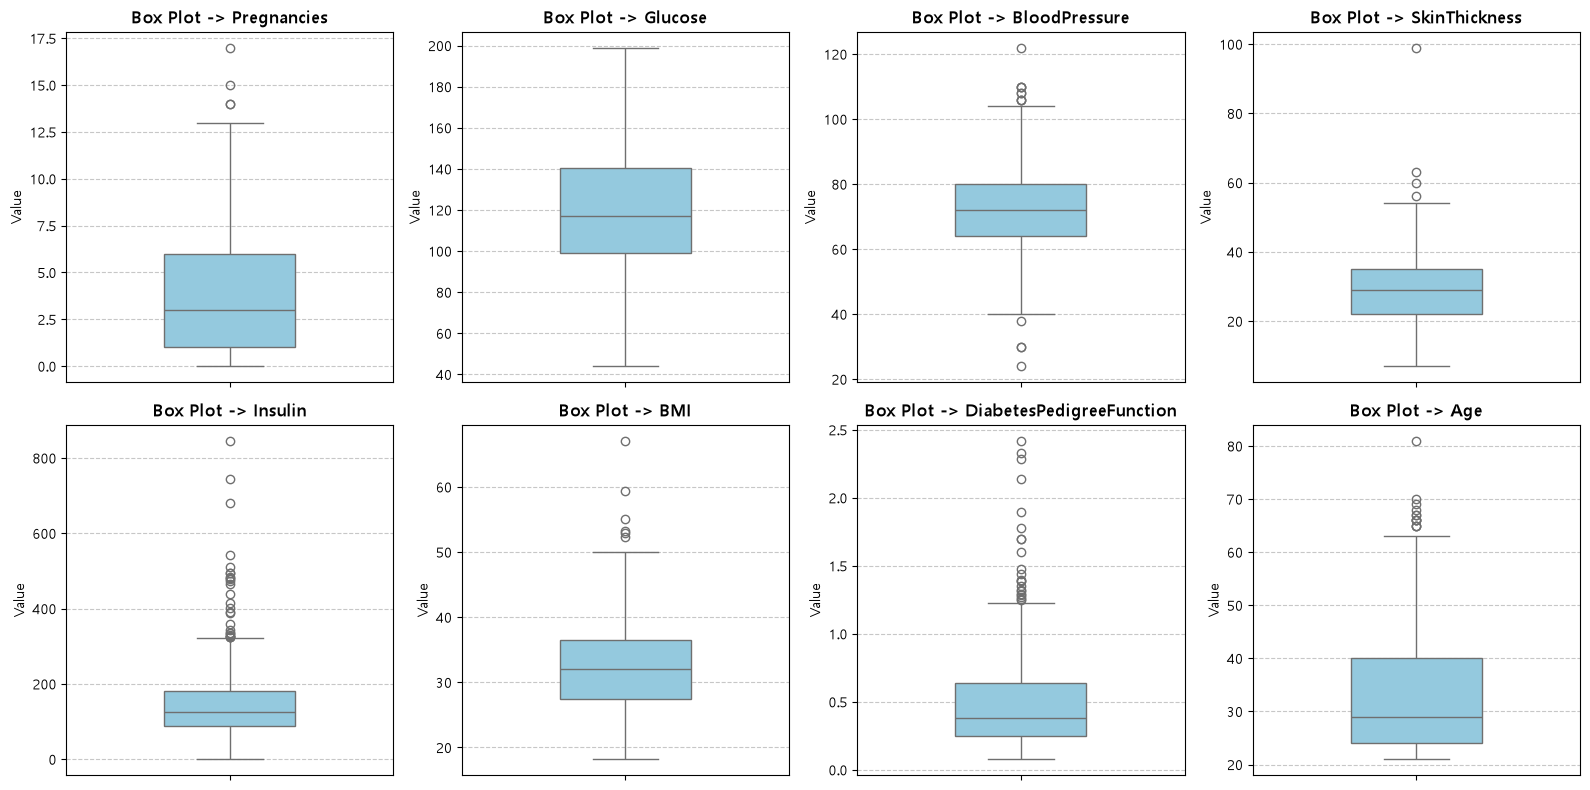

In [37]:
# 1. 시각화 대상 연속형 수치 컬럼 지정
numeric_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 
    'SkinThickness', 'Insulin', 'BMI', 
    'DiabetesPedigreeFunction', 'Age'
]

# 2. 2행 4열 서브플롯 캔버스 생성
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()  # 2D 배열을 1D로 평탄화하여 반복문 접근 용이하게 설정

# 3. 반복문을 통해 각 컬럼별 박스 플롯 생성
# (결측치 대체 완료된 df_clean 또는 X_train_clean 데이터프레임 기준)
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=X_train_clean[col], ax=axes[i], color='skyblue', width=0.4)
    axes[i].set_title(f'Box Plot -> {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# 4. 레이아웃 여백 자동 정렬 및 출력
plt.tight_layout()
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# 이전 단계에서 결측치 처리(IterativeImputer)가 완료된 상태
# (X_train_clean, X_test_clean에 결측치 대체 완료 및 결측지표 생성 완료)

# 연속형 수치 컬럼과 결측 지표(이진 0/1) 컬럼 구분
original_numeric_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 
    'SkinThickness', 'Insulin', 'BMI', 
    'DiabetesPedigreeFunction', 'Age'
]

# 결측 지표 컬럼명 추출 (예: 'missingindicator_Insulin' 형태)
indicator_cols = [col for col in X_train_clean.columns if col not in original_numeric_cols]

# ColumnTransformer 구성
# - original_numeric_cols: StandardScaler 적용
# - indicator_cols: passthrough (변환 없이 원본 0/1 유지)
preprocessor = ColumnTransformer(
    transformers=[
        ('standard_scale', StandardScaler(), original_numeric_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False # 컬럼명 접두사 생략 옵션
)

# 데이터 누수 방지를 위해 Train 세트로만 fit 후 변환
X_train_scaled = preprocessor.fit_transform(X_train_clean)
X_test_scaled = preprocessor.transform(X_test_clean)

# 판다스 데이터프레임으로 복원 (컬럼 순서 및 이름 유지)
feature_names = preprocessor.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train_clean.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test_clean.index)

print("스케일링 완료된 Train 데이터 상위 5개 행:")
print(X_train_final.head())

스케일링 완료된 Train 데이터 상위 5개 행:
     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
200    -1.119892 -0.281756       0.615198      -1.313613 -0.293465 -0.196809   
4      -1.119892  0.498491      -2.569419       0.621280  0.211736  1.572273   
394     0.085345  1.181207       0.455967       0.111927  0.760196  0.080981   
436     2.495819  0.596022       1.013275       0.417607  0.353300  0.738904   
581     0.687963 -0.411797      -0.977111      -0.193411 -0.309131 -1.074039   

     DiabetesPedigreeFunction       Age  SkinThickness_Missing  \
200                  1.140646 -1.027568                    0.0   
4                    5.247773  0.001778                    0.0   
394                  0.934418 -0.169780                    1.0   
436                 -0.689262  0.688009                    0.0   
581                 -0.799637 -0.512895                    0.0   

     Insulin_Missing  
200              1.0  
4                0.0  
394              1.0  
43

In [39]:
# 데이터 EDA 및 시각화를 위하여 다시 합치기
y = pd.concat([y_train, y_test])
X_clean = pd.concat([X_train_final, X_test_final])
X_clean.info()

<class 'pandas.DataFrame'>
Index: 724 entries, 200 to 592
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               724 non-null    float64
 1   Glucose                   724 non-null    float64
 2   BloodPressure             724 non-null    float64
 3   SkinThickness             724 non-null    float64
 4   Insulin                   724 non-null    float64
 5   BMI                       724 non-null    float64
 6   DiabetesPedigreeFunction  724 non-null    float64
 7   Age                       724 non-null    float64
 8   SkinThickness_Missing     724 non-null    float64
 9   Insulin_Missing           724 non-null    float64
dtypes: float64(10)
memory usage: 62.2 KB


In [40]:
# X_clean과 y의 인덱스가 모두 동일한지 확인
print((X_clean.index == y.index).sum() == len(X))

True


## 최종 데이터 시각화
- 결측치 전처리 / 특성 공학(피쳐 엔지니어링) / 데이터 스케일링 완료
- 0/1 바이너리 특성 컬럼(`INSULIN_MISSING`, `SKINTHICKNESS_MISSING`)은 그대로 사용
  - Logistic Regression 기준, 현재 상태로 유의미함

## 시각화를 통한 데이터 특성 분석


제공해주신 상관계수 히트맵과 산점도 행렬(Scatter Matrix)을 바탕으로 분석한 각 특성별 핵심 특징입니다.

| 특성명 | 타겟(`Outcome`) 상관성 | 다중공선성 및 분포 특징 | 모델링 관점의 분석 및 시사점 |
| --- | --- | --- | --- |
| **Glucose** | **0.49 (가장 높음)** | `Insulin`과 강한 양의 상관관계(**0.68**)를 보이며, 산점도에서 뚜렷한 선형 궤적 확인 | 당뇨병 유무(붉은 점 vs 파란 점)를 가장 명확히 가르는 **핵심 예측 인자**입니다. |
| **Insulin** | **0.34 (높음)** | `Glucose`와의 상관계수가 0.68로 매우 높으며, 대치(Imputation) 후에도 우측 꼬리가 두터운 편 | 단독 예측력은 우수하나, Glucose와의 강한 상관관계로 인해 선형 모델에서 회귀 계수 왜곡(다중공선성)을 유발할 수 있습니다. |
| **BMI** | **0.30 (보통 이상)** | `SkinThickness`와 매우 높은 상관관계(**0.70**) | 비만 지표로서 당뇨 발병과 유의미한 양의 관계를 가지며, 체지방 두께와 정보가 강하게 겹칩니다. |
| **SkinThickness** | **0.27 (보통)** | `BMI`와 상관계수 **0.70**, 산점도 상에서도 뚜렷한 대각선 비례 관계 형성 | BMI와 설명력이 중복되므로, 로지스틱 회귀 학습 시 규제(L1/L2)를 주거나 둘 중 하나를 선택적으로 고려할 필요가 있습니다. |
| **Age** | **0.25 (보통)** | `Pregnancies`와 강한 양의 상관관계(**0.56**) | 연령대가 높을수록 당뇨 발병 비율(붉은 점)이 증가하며, 나이에 따른 임신 횟수 증가 경향이 뚜렷합니다. |
| **Pregnancies** | **0.22 (약한 양의 상관)** | `Age`와 높은 상관관계(**0.56**) | 임신 횟수 자체도 위험 요인이지만, 상당 부분 환자의 연령 증가 효과와 얽혀 있습니다. |
| **DiabetesPedigreeFunction** | **0.18 (약한 상관)** | 다른 모든 수치형 특성들과의 상관관계가 극히 낮음 (0.15 이하) | 유전적 요인 지표로, 다른 신체 계측치와 독립적인 고유의 추가 정보(Orthogonal Signal)를 제공합니다. |
| **BloodPressure** | **0.17 (약한 상관)** | `Age`(0.32), `BMI`(0.29)와 소폭 연동되나 타겟 직접 설명력은 낮음 | 정규분포에 가장 가까운 형태를 띠며, 단독으로 당뇨를 구분하기보다는 보조적 지표 역할을 합니다. |
| **SkinThickness_Missing**<br><br>**Insulin_Missing** | **0.04, 0.03 (거의 없음)** | 두 결측 지표 간 상관계수가 **0.65**로 높음 | 결측 사실 자체가 당뇨 발병 여부와 직접 연관되지는 않으나, 두 검사가 세트로 함께 누락되는 경향이 큼을 보여줍니다. |

---

## 데이터 시각화/분석을 통한 인사이트 도출

* **주요 결정 인자:** `Glucose`, `Insulin`, `BMI`가 당뇨 분류(붉은색 레이블 분리)에 가장 결정적인 역할을 수행합니다.
* **다중공선성 주의 구간:** `Glucose - Insulin`($r=0.68$) 쌍과 `SkinThickness - BMI`($r=0.70$) 쌍에서 강한 공선성이 관찰됩니다.
  * 로지스틱 회귀를 적용할 때는 가중치 발산을 막기 위해 L2 규제(`C` 파라미터 조절)를 적용하거나 VIF를 점검하는 것이 필수적입니다.

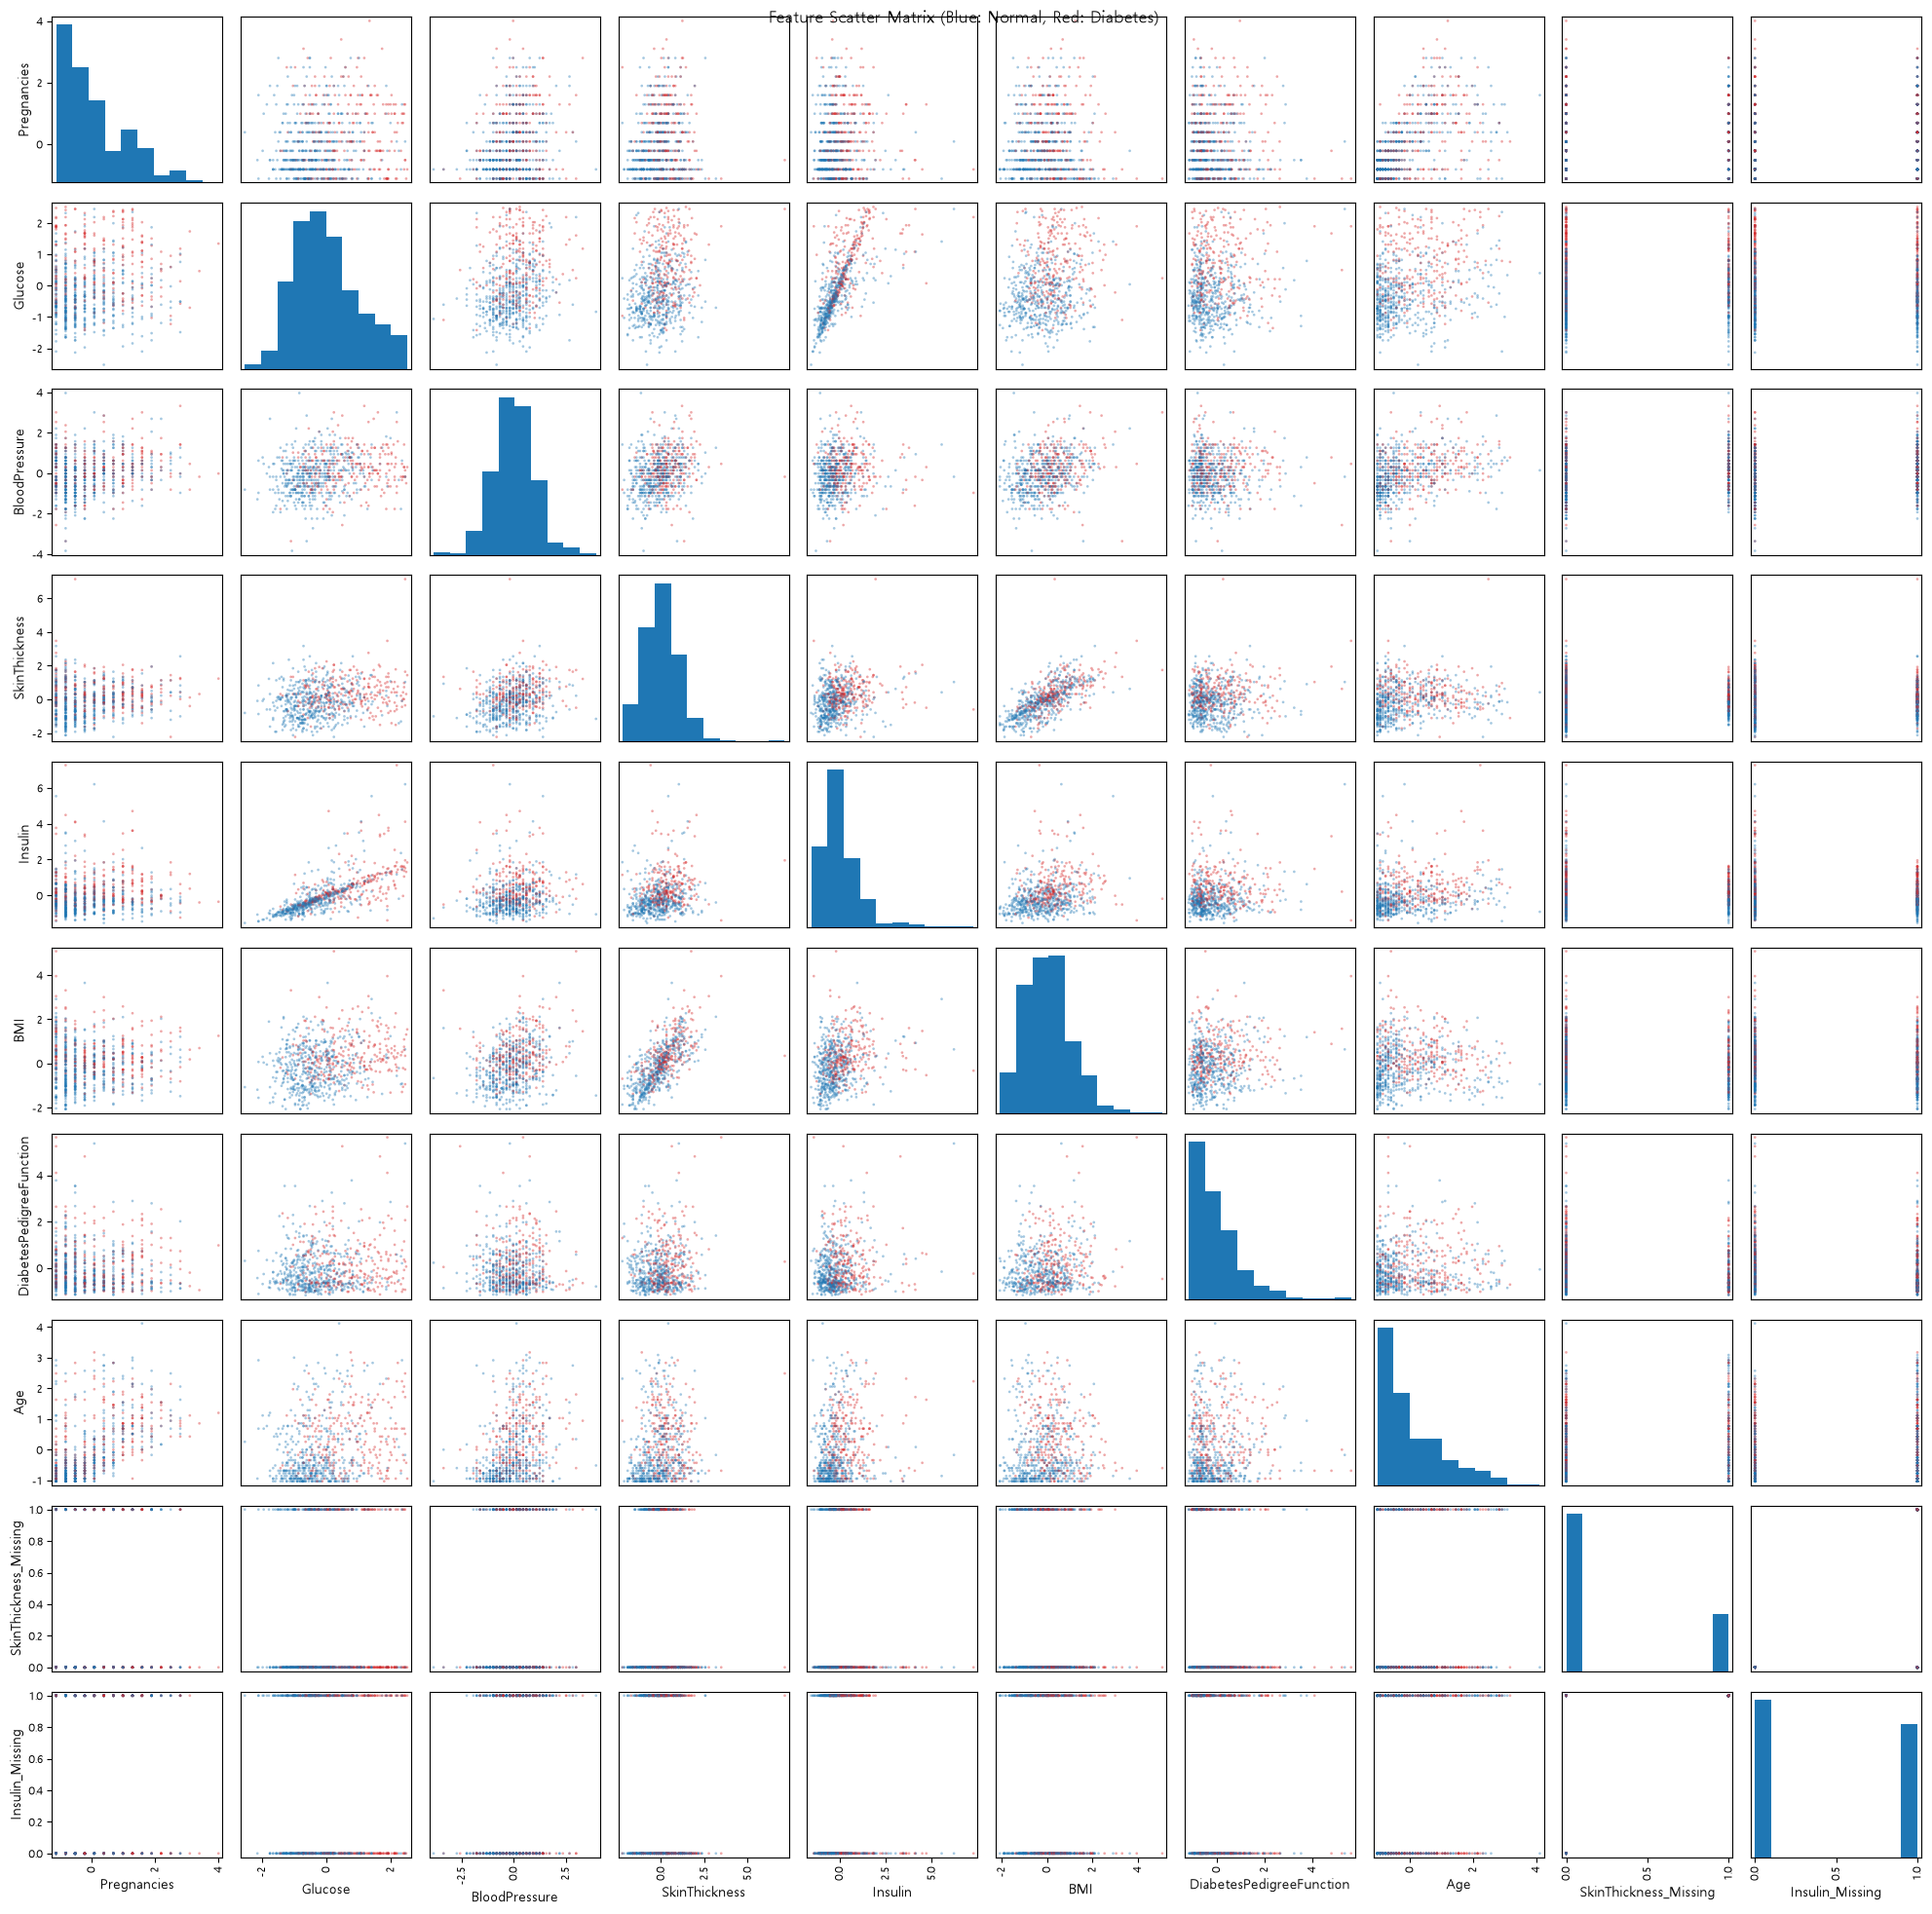

In [41]:
from pandas.plotting import scatter_matrix

# Outcome에 따라 점 색상 매핑 (0: 파랑, 1: 빨강)
colors = y.map({0: '#1f77b4', 1: '#d62728'})

axes = scatter_matrix(
    X_clean,
    c=colors, # 타겟값(당뇨여부)에 따른 컬러맵 적용
    alpha=0.4, # 컬러맵 표현을 위하여 투명값 적용
    figsize=(20, 20),
    diagonal='hist',
    s=15
)
plt.suptitle("Feature Scatter Matrix (Blue: Normal, Red: Diabetes)")
plt.tight_layout()
# 캔버스 이미지 저장 및 출력
plt.savefig("./src/img/feature_scatter_matrix_by_outcome.jpg")
plt.show()

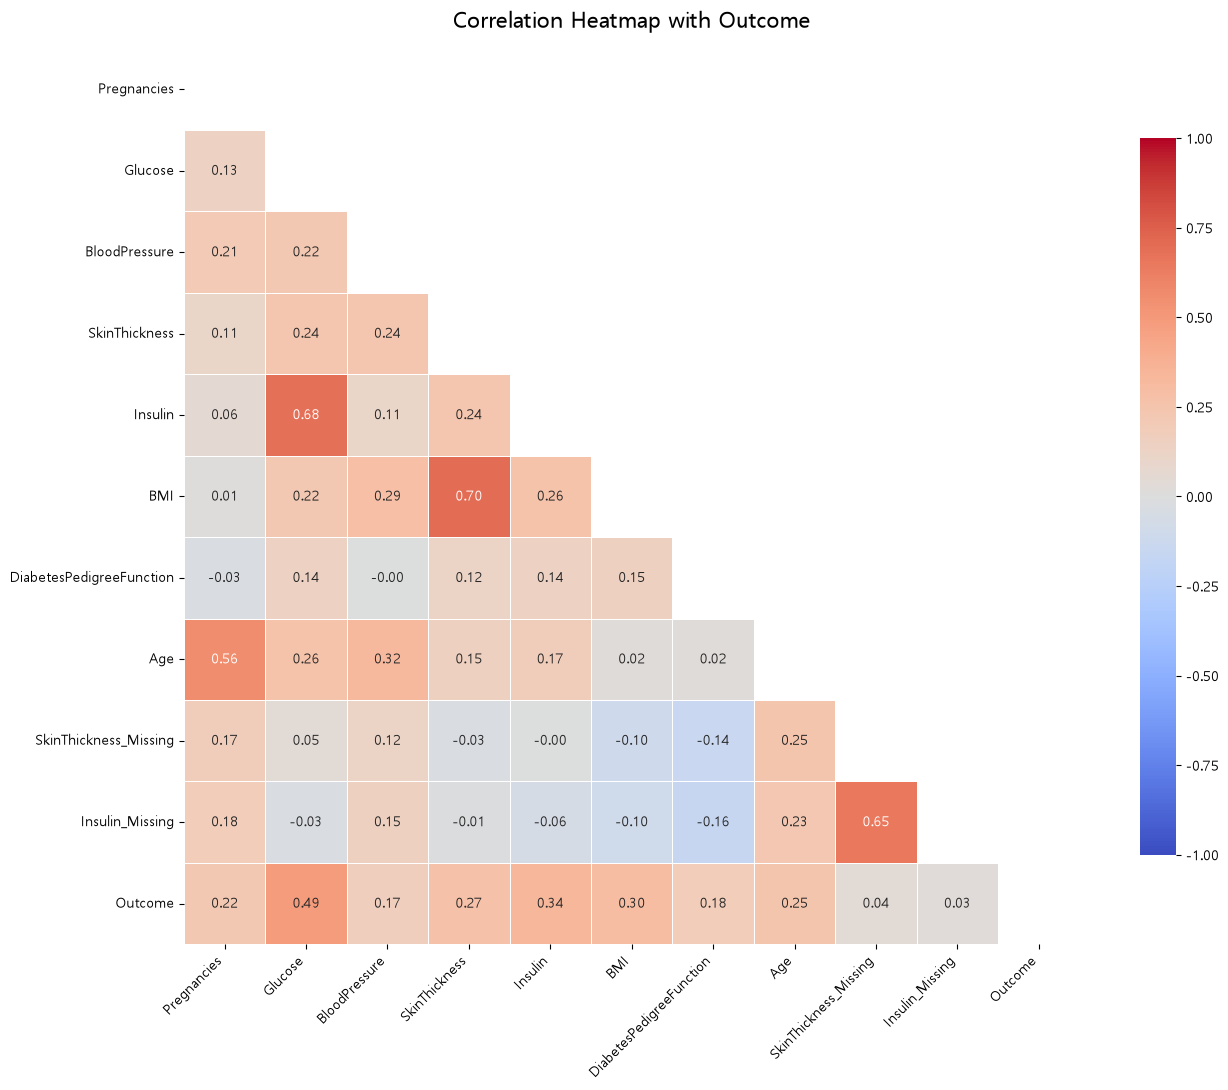

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.concat([X_clean, y], axis=1)

# 1. 상관계수 행렬 계산 (Outcome 포함)
corr = df.corr()

# 2. 대칭되는 상단 삼각형 마스크 생성 (가독성 향상)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. 히트맵 시각화
plt.figure(figsize=(14, 11))

sns.heatmap(
    corr,
    mask=mask,                  # 상단 대칭 영역 가리기
    annot=True,                 # 상관계수 숫자 표시
    fmt=".2f",                  # 소수점 둘째 자리까지
    cmap="coolwarm",            # 양/음의 상관성을 직관적으로 보여주는 컬러맵
    vmin=-1.0,
    vmax=1.0,                   # -1부터 1까지 색상 범위 고정
    linewidths=0.5,             # 셀 간격 구분선
    cbar_kws={"shrink": 0.8},   # 컬러바 크기 조절
    square=True
)

plt.title("Correlation Heatmap with Outcome", fontsize=16, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.savefig("./src/img/corr_heatmap.jpg")
plt.show()

# 2. 머신러닝 모델 학습, 과적합 점검 및 하이퍼파라미터 튜닝

**1️⃣ 구현 내용**

**[필수] 구현 내용**

| **구현 내용** | **설명** |
| --- | --- |
| **[문항 2-1] 회귀 및 분류 모델 학습과 성능 측정** | 전처리가 완료된 데이터를 사용하여 과제 목적에 맞는 회귀 모델과 분류 모델을 각각 정의하여 학습시키고, 각 모델에 부합하는 평가지표(MSE, $R^2$, Accuracy, F1-score 등)를 활용하여 모델의 성능을 측정합니다. |

**[심화] 구현 내용**

| **구현 내용** | **설명** |
| --- | --- |
| **[문항 2-2] 평가지표 선정 근거 및 예측 결과 해석** | 각 과제 유형에서 해당 평가지표를 모델 평가 기준으로 선택한 이유를 명시하고, 최종 측정된 성능 수치에 대한 분석 및 예측 오류가 발생한 원인에 대한 해석을 깊이 있게 기술합니다. |
| **[문항 2-3] 규제, 교차 검증, 하이퍼파라미터 튜닝을 통한 성능 개선** | 모델의 과적합(Overfitting)을 방지하고 성능을 고도화하기 위해 규제(Regularization), 교차 검증(Cross-Validation), 하이퍼파라미터 튜닝(GridSearchCV 등)의 3가지 요소를 모두 적용하여 모델을 개선하고, 개선 전후의 성능을 비교 분석합니다. |

**2️⃣ 결과물**

- **[문항 2-1 결과물]:** 회귀 및 분류 모델 학습 소스 코드와 선정된 평가지표의 최종 성능 수치 출력 화면
- **[문항 2-2 결과물]:** 평가지표 선택 이유, 모델 예측 성능에 대한 분석 및 오류 원인 해석 내용 (마크다운 셀)
- **[문항 2-3 결과물]:** 규제, 교차 검증, 튜닝이 반영된 모델 개선 코드 및 개선 전후의 성능 지표 비교 테이블과 기법별 효과 요약 글 (마크다운 셀)

## 기본 방향성
- 문제 : 당뇨 여부에 대한 이진 분류 예측
- 모델 : 로지스틱 회귀
  - 이유 : feature 대부분이 수치값으로 이루어져 있으며, binary feature 또한 적절하게 처리할 수 있음
- 평가지표 : Binary Cross Entropy (BCE)
  - 이유 : 이진 분류 태스크에 적합한 손실함수 (예측이 정확할수록 Loss = 0에 수렴, 예측이 틀릴수록 Loss = 무한대 증가)
- 성능개선
  - 규제 : L2(릿지) 규제
    - 이유 : Glucose-Insulin, SkinThickness-BMI 간의 강한 상관성 억제 / 극단적인 특성 배제(L1)보다는 점진적인 억제를 통해 예측력 향상 기대
  - 교차검증
    - KFold
      - 이유 : 테스트 데이터가 우연히 모델에 유리하게 구성되어 성능이 과대평가되는 오류(데이터 선택 편향) 발생 방지
  - 하이퍼파라미터 튜닝
    - GridSearchCV
      - 이유 : 상대적으로 적은 데이터샘플(~800) + 상대적으로 가벼운 ML모델(로지스틱회귀) -> 지정 범위 내의 모든 하이퍼파라미터를 로컬 머신 수준에서도 테스트 가능

### (참고/근거) 직전 데이터 시각화로부터 얻은 데이터 인사이트
* **주요 결정 인자:** `Glucose`, `Insulin`, `BMI`가 당뇨 분류(붉은색 레이블 분리)에 가장 결정적인 역할을 수행합니다.
* **다중공선성 주의 구간:** `Glucose - Insulin`($r=0.68$) 쌍과 `SkinThickness - BMI`($r=0.70$) 쌍에서 강한 공선성이 관찰됩니다.
  * 로지스틱 회귀를 적용할 때는 가중치 발산을 막기 위해 L2 규제(`C` 파라미터 조절)를 적용하거나 VIF를 점검하는 것이 필수적입니다.

In [47]:
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import log_loss, accuracy_score, classification_report

## 기본 Logistic Regression 학습 결과
- Test Accuracy : 0.6966
- Cross Entropy (Log Loss) : 0.5936

In [48]:
sklearn.set_config(display="text")

In [49]:
# 직전 전처리 완료 데이터셋
# X_train_final, X_test_final, y_train, y_test

lr = LogisticRegression(random_state=42) # 결과 재현을 위한 random_state
lr.fit(X_train_final, y_train)

LogisticRegression(random_state=42)

In [50]:
y_pred = lr.predict(X_test_final)
acc = accuracy_score(y_test, y_pred)
print(f"이진 분류 테스트 정확도: {acc:.4f}")

# Binary Cross-Entropy 손실 값
y_prob = lr.predict_proba(X_test_final)  # 각 target에 대한 예측 확률값
bce_loss = log_loss(y_test, y_prob)
print(f"BCE Loss : {bce_loss}")

이진 분류 테스트 정확도: 0.6966
BCE Loss : 0.5936143761207342


## 기본 Logistic Regression + KFold(k=5)
Avg. Validation Accuracy: 0.7909
- Fold별 정확도(Accuracy): [0.819  0.8448 0.7931 0.7586 0.7391]

Avg. Cross Entropy (Log Loss): 0.4521
- Fold별 Cross Entropy (Log Loss): [0.4294 0.4146 0.4487 0.4643 0.5036]

In [51]:
# KFold 설정 (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 성능 기록용 리스트
accuracies = []
log_losses = []

# 3. K-Fold 교차 검증 실행
for train_index, test_index in kf.split(X_train_final):
  # print(type(train_index), train_index)
  
  X_train_, X_test_ = X_train_final.iloc[train_index], X_train_final.iloc[test_index]
  y_train_, y_test_ = y_train.iloc[train_index], y_train.iloc[test_index]

  # 로지스틱 회귀 모델 선언 (이진분류, Binary Cross Entropy는 기본 loss_function 적용)
  model = LogisticRegression(random_state=42)

  # 모델 학습
  model.fit(X_train_, y_train_)

  # 예측 및 확률 값 계산
  y_pred = model.predict(X_test_)
  y_pred_proba = model.predict_proba(X_test_)

  # 평가 지표 계산 (정확도 및 Binary Cross Entropy / Log Loss)
  acc = accuracy_score(y_test_, y_pred)
  loss = log_loss(y_test_, y_pred_proba)

  accuracies.append(acc)
  log_losses.append(loss)

# 4. 결과 출력
print(f"Fold별 정확도(Accuracy): {np.round(accuracies, 4)}")
print(f"평균 정확도: {np.mean(accuracies):.4f}")
print(f"Fold별 Cross Entropy (Log Loss): {np.round(log_losses, 4)}")
print(f"평균 Cross Entropy (Log Loss): {np.mean(log_losses):.4f}")

Fold별 정확도(Accuracy): [0.819  0.8448 0.7931 0.7586 0.7391]
평균 정확도: 0.7909
Fold별 Cross Entropy (Log Loss): [0.4294 0.4146 0.4487 0.4643 0.5036]
평균 Cross Entropy (Log Loss): 0.4521


## Logistic Regression(L2, C=2.0) + KFold(k=5)
Avg. Validation Accuracy: 0.7927
- Fold별 정확도(Accuracy): [0.819  0.8534 0.7931 0.7586 0.7391]

Avg. Cross Entropy (Log Loss): 0.4526
- Fold별 Cross Entropy (Log Loss): [0.4297 0.4154 0.4481 0.4649 0.5051]

In [52]:
# KFold 설정 (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 성능 기록용 리스트
accuracies = []
log_losses = []

# 3. K-Fold 교차 검증 실행
for train_index, test_index in kf.split(X_train_final):
  
  X_train_, X_test_ = X_train_final.iloc[train_index], X_train_final.iloc[test_index]
  y_train_, y_test_ = y_train.iloc[train_index], y_train.iloc[test_index]

  # 로지스틱 회귀 모델 선언 (L2 규제 적용)
  model = LogisticRegression(l1_ratio=0, C=2.0, solver='lbfgs', random_state=42)

  # 모델 학습
  model.fit(X_train_, y_train_)

  # 예측 및 확률 값 계산
  y_pred = model.predict(X_test_)
  y_pred_proba = model.predict_proba(X_test_)

  # 평가 지표 계산 (정확도 및 Binary Cross Entropy / Log Loss)
  acc = accuracy_score(y_test_, y_pred)
  loss = log_loss(y_test_, y_pred_proba)

  accuracies.append(acc)
  log_losses.append(loss)

# 4. 결과 출력
print(f"Fold별 정확도(Accuracy): {np.round(accuracies, 4)}")
print(f"평균 정확도: {np.mean(accuracies):.4f}")
print(f"Fold별 Cross Entropy (Log Loss): {np.round(log_losses, 4)}")
print(f"평균 Cross Entropy (Log Loss): {np.mean(log_losses):.4f}")

Fold별 정확도(Accuracy): [0.819  0.8534 0.7931 0.7586 0.7391]
평균 정확도: 0.7927
Fold별 Cross Entropy (Log Loss): [0.4297 0.4154 0.4481 0.4649 0.5051]
평균 Cross Entropy (Log Loss): 0.4526


In [53]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 탐색할 하이퍼파라미터 그리드 설정
# - C: 규제 강도의 역수 (작을수록 강한 규제)
# - l1_ratio : 규제 종류, l1_ratio=0 for L2, l1_ratio=1 for L1
# - solver: 최적화에 사용할 알고리즘
param_grid = [{
    'C': np.logspace(-2, 2, 19),
    'l1_ratio': [1, 0], # l1_ratio=0 for L2, l1_ratio=1 for L1
    'solver': ['liblinear'],
    'max_iter' : [50, 100, 1000, 5000]
},
{
    'C': np.logspace(-2, 2, 19),
    'l1_ratio': [0], # l1_ratio=0 for L2, l1_ratio=1 for L1
    'solver': ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag'],
    'max_iter' : [50, 100, 1000, 5000]
}             
]


# 5. 로지스틱 회귀 모델 초기화
# Increased max_iter helps solvers converge
lr_model = LogisticRegression(random_state=42)

# 6. GridSearchCV 객체 생성
# - cv=5: 5-Fold 교차 검증 사용
# - scoring='neg_log_loss': 이진 분류 평가지표로 Binary Cross Entropy 사용
grid_search = GridSearchCV(estimator=lr_model, param_grid=param_grid, cv=kf, scoring='neg_log_loss', n_jobs=-1)

# 7. 그리드 서치 수행 (학습)
grid_search.fit(X_train_final, y_train)

# 8. 최적의 파라미터 및 최고 점수 출력
print(f"최적의 하이퍼파라미터: {grid_search.best_params_}")
print(f"교차 검증 최저 손실값: {-1 * grid_search.best_score_:.4f}")

# 9. 베스트 모델 최종 test accuracy 출력
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_final)
acc = accuracy_score(y_test, y_pred)

print(f"GridSearch 베스트 모델 - 이진 분류 테스트 정확도: {acc:.4f}")

최적의 하이퍼파라미터: {'C': np.float64(0.3593813663804626), 'l1_ratio': 1, 'max_iter': 50, 'solver': 'liblinear'}
교차 검증 최저 손실값: 0.4485
GridSearch 베스트 모델 - 이진 분류 테스트 정확도: 0.7034


## 전처리X, 정규화 및 하이퍼파라미터 최적화 X 할때의 비교 결과

- 전처리, 정규화, 하이퍼파라미터 최적화를 하지 않았을 경우가 test accuracy가 더 높게 나옴

### Gemini 분석 결과:

전처리와 하이퍼파라미터 튜닝(GridSearchCV)을 거쳤음에도 전처리하지 않은 원본 모델보다 테스트 정확도가 떨어지는 현상은 **피마 인디언 당뇨병 데이터셋(Pima Diabetes)과 로지스틱 회귀의 특성** 때문에 빈번하게 발생하는 대표적인 역설입니다.

노트북에서 작성하신 파이프라인을 분석했을 때, 성능 저하를 유발한 핵심 원인은 크게 5가지입니다.

---

**1. 평가 대상(Test Set)의 불일치 가능성**

* **전처리 전 데이터(768개) vs 44개 행을 삭제한 데이터(724개):**
* 결측치로 판단한 44개 행(`Glucose`, `BloodPressure`, `BMI`가 0인 행)을 train/test 분할 **이전에** 삭제했습니다.
* 만약 '전처리 없는 기본 모델'을 768개 전체 데이터를 기준으로 분할해 테스트했다면, **두 모델은 서로 다른 테스트셋으로 평가된 것**입니다.
* 제거된 44개 샘플은 당뇨 여부를 판별하기 아주 쉽거나(혹은 특정 레이블에 치우친) 데이터였을 확률이 높아, 테스트셋의 모수와 분포가 달라지면서 단순 정확도 비교가 무의미해집니다.



---

**2. 50%에 달하는 인슐린 결측치의 '다변량 대체(MICE)'로 인한 다중공선성 폭증**

* `Insulin`은 전체의 절반가량(374건)이 결측치(0)였습니다.
* `IterativeImputer(BayesianRidge)`는 `Glucose`, `BMI`, `Age` 등의 선형 결합으로 `Insulin`의 빈자리를 채웁니다.
* 결과적으로 "대체된 인슐린"은 기존 `Glucose`와 `BMI`의 복제품(강한 상관관계)이 됩니다.
* 로지스틱 회귀와 같은 선형 모델은 독립변수 간 다중공선성(Multicollinearity)에 매우 취약합니다. 가장 중요한 단독 예측 인자인 `Glucose`의 신호(Signal)가 인슐린과 분산되면서 모델의 가중치 추정이 불안정해져 일반화 성능이 저하됩니다.

---

**3. 극단적 이상치가 존재하는 상태에서 `StandardScaler` 적용**

* 노트북의 분석 내용처럼 `Insulin`(최댓값 846)과 `DiabetesPedigreeFunction`, `Age`는 오른쪽 꼬리가 매우 긴 심한 비대칭(Right-skewed) 분포를 띱니다.
* 이상치가 큰 상태에서 `StandardScaler`를 적용하면 평균($\mu$)과 표준편차($\sigma$)가 극단값 쪽으로 크게 왜곡됩니다.
* 이로 인해 정상 범위에 모여 있는 대다수 환자들의 수치가 0 주변의 아주 좁은 구간으로 압축(Squashing)되어, 로지스틱 회귀가 결정 경계(Decision Boundary)를 뚜렷하게 가르지 못하게 됩니다.

---

**4. '0' 자체에 담긴 의학적 결측 의미(MNAR) 소실**

* 의학 데이터에서 검사 수치 누락은 무작위 결측(MCAR)이 아니라 비무작위 결측(MNAR: Missing Not At Random)인 경우가 많습니다. (예: 증상이 뚜렷하지 않거나 특정 검진 단계가 생략된 환자군)
* 원본 데이터의 '0'은 로지스틱 회귀 입장에서 일종의 '극단값 형태의 경계선 플래그' 역할을 은연중에 수행하고 있었을 수 있습니다. 이를 회귀식으로 부드럽게 채워 넣으면서 오히려 당뇨 환자와 비당뇨 환자 간의 날카로운 경계 정보가 희석되었을 가능성이 큽니다.

---

**5. 소규모 데이터셋(N=579)에서의 GridSearchCV 과적합**

* 전처리 후 학습 데이터는 579개에 불과하며, 5-Fold 교차검증을 수행하면 검증 폴드당 샘플 수는 115개 내외입니다.
* 데이터 크기가 작을 때 `GridSearchCV`로 규제 매개변수 $C$나 페널티를 탐색하면 교차검증 폴드의 특정 노이즈에 과적합(Overfitting)된 파라미터가 선택되기 쉽습니다.
* scikit-learn의 `LogisticRegression` 기본값(`C=1.0`, `penalty='l2'`)은 보수적이면서도 일반화 성능이 우수한 세팅이므로, 튜닝된 모델이 기본 모델보다 테스트 성능이 떨어지는 일이 흔히 발생합니다.

---

**성능 개선을 위한 제안**

* **변수 제거 실험:** 결측 비율이 30~50%인 `Insulin`과 `SkinThickness`를 억지로 대체하지 않고 컬럼 자체를 `drop`한 뒤 `Glucose`, `BMI`, `Age`, `Pregnancies` 위주로 로지스틱 회귀를 학습시켜 보세요.
* **스케일러 변경 및 로그 변환:** `Insulin`, `DiabetesPedigreeFunction` 등 왜도가 심한 컬럼에 `np.log1p()` 변환을 적용하거나 `RobustScaler`를 사용하세요.
* **L1 규제(Lasso) 검토:** 늘어난 특성 및 다중공선성 완화를 위해 `LogisticRegression(penalty='l1', solver='liblinear')`을 적용해 불필요한 가중치를 0으로 제거해 봅니다.


## 의사결정
### 2. 다중공선성 폭증
- L1 정규화를 사용하여 상관성이 높은 변수를 완전히 억제한다.

### 3. StandardScaler
- RobustScaler로 교체 적용한다.

### 4. '0' 데이터에 담긴 정보 소실
- Insulin, SkinThickness의 결측치 여부를 표현하는 컬럼을 특성 공학으로 추가하였으므로 해당 이슈는 큰 영향 없을 것으로 판단

### 5. KFold 폴드 갯수
- 폴드의 갯수를 기존 5개에서 3개로 줄인다.

In [54]:
# 데이터 전처리하지 않음 + 기본 로지스틱 회귀 모델
data = pd.read_csv('./src/data/diabetes.csv', encoding='utf-8')
X = data.drop('Outcome', axis=1)
y = data['Outcome']
X_train_, X_test_, y_train_, y_test_ = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

lr_ = LogisticRegression(random_state=42, max_iter=1000) # 결과 재현을 위한 random_state
lr_.fit(X_train_, y_train_)

y_pred_ = lr_.predict(X_test_)
acc_ = accuracy_score(y_test_, y_pred_)
print(f"이진 분류 테스트 정확도: {acc_:.4f}")

# Binary Cross-Entropy 손실 값
y_prob_ = lr_.predict_proba(X_test_)  # 각 target에 대한 예측 확률값
bce_loss_ = log_loss(y_test_, y_prob_)
print(f"BCE Loss : {bce_loss_}")

이진 분류 테스트 정확도: 0.7143
BCE Loss : 0.495922019570397


In [55]:
############################
#### 의사결정 적용 후 테스트 ####
############################

#### RobustScaler ####

from sklearn.preprocessing import RobustScaler
# RobustScaler
original_numeric_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 
    'SkinThickness', 'Insulin', 'BMI', 
    'DiabetesPedigreeFunction', 'Age'
]
indicator_cols = [col for col in X_train_clean.columns if col not in original_numeric_cols]
preprocessor = ColumnTransformer(
    transformers=[
        ('robust_scale', RobustScaler(), original_numeric_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False # 컬럼명 접두사 생략 옵션
)
X_train_scaled2 = preprocessor.fit_transform(X_train_clean)
X_test_scaled2 = preprocessor.transform(X_test_clean)

feature_names = preprocessor.get_feature_names_out()
X_train_final2 = pd.DataFrame(X_train_scaled2, columns=feature_names, index=X_train_clean.index)
X_test_final2 = pd.DataFrame(X_test_scaled2, columns=feature_names, index=X_test_clean.index)


#### KFold(k=3) + GridSearchCV(L1 regularization)
kf2 = KFold(n_splits=3, shuffle=True, random_state=42)

param_grid2 = [{
    'C': np.logspace(-3, 3, 30),
    'l1_ratio': [1], # l1_ratio=0 for L2, l1_ratio=1 for L1
    'solver': ['liblinear'],
    'max_iter' : [20, 35, 50, 100]
}
]

lr_model2 = LogisticRegression(random_state=42)
grid_search2 = GridSearchCV(estimator=lr_model2, param_grid=param_grid2, cv=kf2, scoring='neg_log_loss', n_jobs=-1)
grid_search2.fit(X_train_final2, y_train)

print(f"최적의 하이퍼파라미터: {grid_search2.best_params_}")
print(f"교차 검증 최저 손실값: {-1 * grid_search2.best_score_:.4f}")

best_model2 = grid_search2.best_estimator_
y_pred2 = best_model2.predict(X_test_final2)
acc2 = accuracy_score(y_test, y_pred2)
print(f"GridSearch 베스트 모델 - 이진 분류 테스트 정확도: {acc2:.4f}")

최적의 하이퍼파라미터: {'C': np.float64(0.3039195382313198), 'l1_ratio': 1, 'max_iter': 20, 'solver': 'liblinear'}
교차 검증 최저 손실값: 0.4555
GridSearch 베스트 모델 - 이진 분류 테스트 정확도: 0.7034


In [56]:
########################################################
#### Insulin, SkinThickness 컬럼 배제 후 최종 테스트 ########
########################################################


X_train_clean2 = X_train_clean.drop(columns=['Insulin', 'SkinThickness'])
X_test_clean2 = X_test_clean.drop(columns=['Insulin', 'SkinThickness'])

original_numeric_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 
    'BMI', 'DiabetesPedigreeFunction', 'Age'
]
indicator_cols = [col for col in X_train_clean2.columns if col not in original_numeric_cols]
preprocessor = ColumnTransformer(
    transformers=[
        ('robust_scale', RobustScaler(), original_numeric_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False # 컬럼명 접두사 생략 옵션
)
X_train_scaled3 = preprocessor.fit_transform(X_train_clean2)
X_test_scaled3 = preprocessor.transform(X_test_clean2)

feature_names = preprocessor.get_feature_names_out()
X_train_final3 = pd.DataFrame(X_train_scaled3, columns=feature_names, index=X_train_clean2.index)
X_test_final3 = pd.DataFrame(X_test_scaled3, columns=feature_names, index=X_test_clean2.index)


#### KFold(k=3) + GridSearchCV(L1 regularization)
kf2 = KFold(n_splits=3, shuffle=True, random_state=42)

param_grid3 = [{
    'C': np.logspace(-3, 3, 30),
    'l1_ratio': [1, 0], # l1_ratio=0 for L2, l1_ratio=1 for L1
    'solver': ['liblinear'],
    'max_iter' : [30, 50, 100]
},
{
    'C': np.logspace(-3, 3, 30),
    'l1_ratio': [0], # l1_ratio=0 for L2, l1_ratio=1 for L1
    'solver': ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag'],
    'max_iter' : [30, 50, 100]
}             
]

lr_model3 = LogisticRegression(random_state=42)
grid_search3 = GridSearchCV(estimator=lr_model3, param_grid=param_grid3, cv=kf2, scoring='neg_log_loss', n_jobs=-1)
grid_search3.fit(X_train_final3, y_train)

print(f"최적의 하이퍼파라미터: {grid_search3.best_params_}")
print(f"교차 검증 최저 손실값: {-1 * grid_search3.best_score_:.4f}")

best_model3 = grid_search3.best_estimator_
y_pred3 = best_model3.predict(X_test_final3)
acc3 = accuracy_score(y_test, y_pred3)
print(f"GridSearch 베스트 모델 - 이진 분류 테스트 정확도: {acc3:.4f}")

최적의 하이퍼파라미터: {'C': np.float64(0.3039195382313198), 'l1_ratio': 1, 'max_iter': 30, 'solver': 'liblinear'}
교차 검증 최저 손실값: 0.4547
GridSearch 베스트 모델 - 이진 분류 테스트 정확도: 0.7034


## 과제 1,2 결론

- 전처리X 최적화X 베이스라인 대비 전처리 및 하이퍼파라미터 최적화의 test accuracy 성능 개선 효과 없었음
  - BCE Loss 기준으로는 소폭 성능 향상(0.49 -> 0.45) 되어, 일반화 성능은 다소 나아졌다고 볼 수 있음
- 추정되는 원인
  - 로지스틱 회귀 모델 자체의 성능 한계 + 다중공선성에 취약한 특성
  - 최초 drop한 44개의 샘플이 예상보다 더 중요한 데이터 샘플이었을 가능성
    - 평균 또는 중앙값으로 대체하고 그대로 사용하는 것이 더 좋았을 것 같음
  - 데이터 샘플이 충분하지 않았음 + 'Age'-'Pregnancies' 등의 변수 간 상관관계를 규제로 충분히 억제할 수 없었음

# 3. Hugging Face 사전 학습된 모델을 활용한 뉴스 기사 분류 및 추론

**1️⃣ 구현 내용**

**[필수] 구현 내용**

| **구현 내용** | **설명** |
| --- | --- |
| **[문항 3-1] 사전 학습된 모델 및 토크나이저 로드** | Hugging Face 라이브러리를 활용하여 사전 학습된(Pre-trained) Gemma 모델과 토크나이저를 독립된 개발 환경 내에 그대로 로드하는 코드를 구현합니다. |
| **[문항 3-2] 문맥 내 학습(In-context Learning) 기반 뉴스 기사 분류 추론** | 뉴스 기사 텍스트를 분류하기 위해, 프롬프트 내에 정답 카테고리 예시들을 제공하는 Few-shot 프롬프트 구조(문맥 내 학습)를 설계합니다. 별도의 가중치 파인튜닝 없이 사전 학습된 가중치 그대로 뉴스 기사 텍스트를 입력하여 카테고리 추론(Inference) 결과를 도출합니다. |

**[심화] 구현 내용**

| **구현 내용** | **설명** |
| --- | --- |
| **[문항 3-3] Generation 하이퍼파라미터 변경 실험 및 성능 비교 해석** |   • 텍스트 생성 결과의 다양성과 무작위성을 제어하는 **Generation 하이퍼파라미터(temperature, top_p , top_k 등) 설정을 변경**하거나 프롬프트 내 Few-shot 예시의 개수를 바꾸어 추가 추론 실험을 수행합니다. <br> • 하이퍼파라미터 조건 변경에 따라 모델이 출력한 분류 결과의 정확도와 답변의 일관성이 어떻게 변화하는지 비교 분석하고 해석하는 내용을 마크다운 셀에 기술합니다. |

**2️⃣ 결과물**

- **[문항 3-1 결과물]:** Hugging Face 기반 사전학습 Gemma 모델 및 토크나이저 로드 소스 코드와 출력 화면
- **[문항 3-2 결과물]:** 문맥 내 학습(Few-shot)을 위한 프롬프트 구성 및 추론 프로세스 구현 코드와 카테고리 분류 출력 화면
- **[문항 3-3 결과물]:** 생성 하이퍼파라미터 설정별 변경 실험 조건 표 및 결과에 따른 출력 성능 비교 분석 내용 (마크다운 셀)

교안
* https://teamsparta.notion.site/3ae2dc3ef51480488366d3386c5c5cc1

과제제출가이드
* https://teamsparta.notion.site/AX_1-Ch-1-3c72dc3ef51480b7abbaedb953ca28dd
* https://app.notion.com/p/teamsparta/KANT-3d02dc3ef51480c599c2c80fb53be7aa


In [ ]:
# uv add transformers torch sentencepiece accelerate

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 가속 연산 디바이스(GPU/MPS) 자동 설정
# CUDA(NVIDIA) -> MPS(Mac 인텔/실리콘) -> CPU 순으로 사용 가능한 자원을 체크합니다.
device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu"
)
print(f"현재 연산에 사용 중인 디바이스: {device}")

c:\Users\dance\Documents\kant-ml-final-assignment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


현재 연산에 사용 중인 디바이스: cpu


In [2]:
from transformers import pipeline
import torch

# Gemma 인스트럭션 모델 식별자 설정
gemma_identifier = "google/gemma-2b-it"

# 텍스트 생성 파이프라인 구축 (bfloat16 연산 및 자원 자동 배치 적용)
gemma_generator = pipeline(
    "text-generation",
    model=gemma_identifier,
    dtype=torch.bfloat16,
    device_map="auto" # accelerate를 통해 OS별 하드웨어(CUDA/MPS) 최적 자동 할당
)

Loading weights: 100%|██████████| 164/164 [00:00<00:00, 14041.52it/s]


In [ ]:
# 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(gemma_identifier)

# 토크나이저 테스트
prompt = "Hello, how are you today?"
inputs = tokenizer(prompt, return_tensors="pt")

print("\nToken IDs:", inputs["input_ids"])
print("Decoded text:", tokenizer.decode(inputs["input_ids"][0]))


Token IDs: tensor([[     2,   4521, 235269,   1368,    708,    692,   3646, 235336]])
Decoded text: <bos>Hello, how are you today?


In [3]:
def set_news_category_dialogue(news_text):
   # 대화형 프롬프트 구조 정의
   # gemma-2b-it -> system role을 지원하지 않으므로, 첫 입력에 system role 텍스트를 포함하여 모델이 이해하도록 구성
   user_dialogue = [
      {"role": "user",
      "content": 
         """
         system:
         당신은 뉴스 기사 텍스트를 분류하는 전문가입니다. 사용자가 입력한 뉴스 기사 텍스트를 기반으로, 해당 기사가 정치, 경제, 사회, 문화, 스포츠 등 어떤 분야에 속하는지 분류해 주세요.
         뉴스 기사 분류에 다음 5가지 범주를 사용합니다: 정치, 경제, 사회, 문화, 스포츠.
         각 범주에 대한 뉴스 기사 텍스트 예시는 다음과 같습니다.
         
         [정치]
         더불어민주당은 국민의힘 한동훈 의원을 향해 “김승원 법무부 장관 후보자를 향한 공세를 '캐비닛 정치'로 규정하며 즉각 중단하라”고 촉구했다.
         조계원 더불어민주당 대변인은 6일, 서면브리핑을 통해 "김승원 법무부 장관 후보자의 식약처 민원은 코로나19 치료제 개발이 국가적 과제였던 지난 2021년, 국내 중소기업이 부당한 불이익을 받지 않도록 살펴봐 달라는 공익적 고충민원이었다"며 "이를 범죄로 몰아가는 한동훈 의원과 국힘의 주장은 과도한 억측이자 흑색선전"이라고 비판했다.
         사건의 경위에 대해서는 "2022년 11월 대검찰청 첩보 이첩으로 시작되어 당시 한동훈 법무부 장관·이원석 검찰총장 체제에서 수사가 본격화됐고, 이후 박성재 법무장관·심우정 검찰총장 체제에서 기소유예 처분이 내려졌다"며 "수사부터 처분까지 모두 윤석열 정부에서 이루어진 광범위한 표적 수사였다"고 지적했다.

         [경제]
         코스피지수가 2개월 만에 6000대로 후퇴한 데 대해 전문가들은 “과도한 하락”이라고 진단했다. 반도체 고점 논란과 레버리지 상장지수펀드(ETF)에 따른 수급 꼬임, 중동 전쟁 등이 겹치며 과매도가 이뤄졌다는 분석이다. 이달 말 발표될 예정인 미국 빅테크 실적을 ‘9천피’ 회복을 위한 최대 변수로 지목했다.
         13일 한국경제신문이 국내 주요 증권사 리서치센터장과 시황팀장 등을 대상으로 긴급 설문조사한 결과 코스피지수가 6000대까지 밀린 건 과도하다는 의견이 지배적이었다. 이진우 메리츠증권 리서치센터장은 “실적을 고려하면 과매도권”이라며 “주가수익비율(PER)이 6배 수준까지 내려온 건 매우 이례적”이라고 설명했다. 김석환 미래에셋증권 수석연구위원은 “이익 전망 훼손보다 공포가 가격에 과도하게 반영된 수준”이라고 진단했다.
         증시 조정 이유로는 반도체 피크아웃 우려를 공통적으로 언급했다. 황승택 하나증권 리서치센터장은 “메모리 반도체 업황에 대한 고점 우려와 투자심리 악화가 주된 원인”이라며 “삼성전자 실적은 양호했지만 시장 기대치에는 미치지 못했다”고 설명했다.
         SK하이닉스 영업이익이 시장 컨센서스를 8% 밑돌 것이란 한국투자증권 보고서도 투자심리 악화로 이어졌다. 채민숙 한국투자증권 연구원은 “체결된 장기공급계약(LTA)을 바탕으로 가격 가정을 반영한 결과 올해와 내년 영업이익 전망치를 기존 대비 각각 9%, 11% 하향 조정했다”고 말했다.

         [사회]
         광복절 연휴 극한호우로 막대한 피해를 본 경남 거제와 통영지역에 응급복구가 마무리됐으나 여전히 개인 피해 복구는 더뎌 주민들은 애가 탄다.
         5일 경남도에 따르면 전날 기준 거제와 통영지역 수해 응급복구율은 100％로 집계됐다.
         응급복구는 도로와 하천, 상수도 등 공공시설과 단독주택을 비롯한 주거시설 등 '생활밀착형 시설'을 대상으로 진행됐다.
         그러나 생활밀착형 시설이 아닌 개인 사업장 등 일반 사유시설은 복구가 더딘 상황이어서 피해 주민들은 막막하다고 호소한다.
         거제시 둔덕면에서 캠핑장을 운영하는 30대 자영업자 전모 씨는 "지난 4일 복구를 시작해 아직 복구 작업이 많이 남았다"고 토로했다.
         광복절 연휴 거제에 900㎜가 넘는 비가 쏟아진 탓에 전씨 캠핑장은 그야말로 난장판이 됐다.
         주변 산에서 내려온 토사와 돌무더기가 캠핑장 터를 덮쳤지만, 개인이 중장비를 쉽게 동원하기 어려운 상황이어서 그동안 복구가 계속 지연됐다.
         전씨는 "공공시설이나 주거시설 복구가 우선인 상황은 이해하지만, 자연재해로 인한 피해이기 때문에 지원이 절실한 상황이다"고 말했다.
         
         [문화]
         빛은 찰나를 스치고, 화가는 그 순간을 붙잡았다. 미술 교과서에서만 만나던 모네와 르누아르, 반 고흐, 세잔의 원화가 올가을 광주를 찾는다.
         국립아시아문화전당재단(사장 김명규, 이하 ‘전당재단’)은 9월 23일 개막하는 하반기 특별전 ‘인상파, 찬란한 순간들: 모네, 르누아르, 반 고흐 그리고 세잔’의 조기 예매를 8월 10일부터 9월 22일까지 진행한다고 밝혔다.
         이번 전시는 세계적 국립기관인 예루살렘 이스라엘박물관이 소장한 인상주의·후기 인상주의 거장 11인의 대표작 21점을 한자리에서 선보이는 대형 기획전이다. 전남광주통합특별시 출범 이후 처음 열리는 세계적 규모의 인상파 원화전이라는 점에서 지역 문화계의 관심이 쏠린다.
         전시는 내년 2월 21일까지 국립아시아문화전당 복합전시 6관과 7관에서 이어진다. 19세기 후반 아카데미즘과 살롱 중심의 전통 회화에서 벗어나 빛과 자연, 순간의 감각을 화폭에 담아낸 인상파 작가들의 예술세계를 집중적으로 조명한다.

         [스포츠]
         “오타니의 건강에 대한 불확실성이 날이 갈수록 커지고 있다.”
         LA 다저스 오타니 쇼헤이(32)의 왼 무릎, 목, 이두근 통증이 가볍지 않다. 4일(이하 한국시각) 세인트루이스 카디널스전, 5~6일 워싱턴 내셔널스전에 잇따라 결장했다. 이런 상황서 오타니가 지난달 18일부터 미국 언론들의 취재를 거부하고 있다는 사실이 밝혀지기도 했다.
         데이브 로버츠 감독, 브랜든 고메스 단장은 오타니의 부상자명단 등재에 대해선 논의한 적이 없다고 했다. 그러나 로버츠 감독은 그것이 옵션 중 하나라고 밝히긴 했다. 현 시점에서 더 이상 오타니의 투수 복귀 시점을 논하는 것은 의미가 없다. 타자로도 3일 연속 결장했다.
         오타니의 미래를 위해, 다저스의 월드시리즈 3연패를 위해 결단을 내릴 시점이다. 일단 부상자명단 등재는 오타니가 원하지 않는 것으로 보인다. 다저스가 다른 선수도 아니고 천하의 슈퍼스타 오타니를 마음대로 어떻게 할 수 없기 때문이다.        

         **추가적으로, 답변 출력 시 다음 사항을 지켜 주세요.**
            - 사용자의 입력 텍스트에 대해 5개 카테고리 중 단 1개의 카테고리만 선택하여 답변합니다.
            - 해당 카테고리를 선택한 이유를 한 문장으로 간결하게 설명합니다.
            - [카테고리 명칭]과 [카테고리 선택 이유]를 JSON 형식으로 종합하여 결과를 출력합니다.
            - JSON 출력 포맷 예시는 다음과 같습니다:
            {"category": "정치", "reason": "뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다."}
         """},
         {"role": "assistant",
               "content": 
                  """
                  알겠습니다. 사용자가 입력한 뉴스 기사 텍스트를 기반으로, 해당 기사가 정치, 경제, 사회, 문화, 스포츠 중 어떤 분야에 속하는지 분류하고, 그 이유를 설명하겠습니다. 
                  카테고리 명칭과 카테고리 선택 이유를 JSON 형식으로 종합하여 결과를 출력하겠습니다.
                  JSON 포맷은 {"category": "정치", "reason": "뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다."} 형태로 제공됩니다.
                  """
         },
         {"role": "user",
            "content": 
               f"""
               다음 뉴스 기사의 카테고리를 분류하고 그 이유를 설명해 주세요. 뉴스 기사 텍스트는 아래와 같습니다.
               
               [뉴스 기사 텍스트]
               {news_text}
               """
         }
   ]

   return user_dialogue

news = "글로벌 이스포츠 미디어 네트워크 ESTV(Esports Television)는 세계 최대 규모의 글로벌 이스포츠 축제인 Esports World Cup(EWC)과 2026년 공식 방송 파트너십을 체결하며 2년 연속 협력을 이어간다고 발표했다. 이번 파트너십을 통해 ESTV는 2026년 프랑스 파리에서 개최되는 EWC 주요 경기와 특별 프로그램, 하이라이트 콘텐츠, 선수 인터뷰 및 현장 스페셜 프로그램 등을 글로벌 방송 플랫폼과 디지털 채널을 통해 전 세계 시청자들에게 제공할 예정이다."
generation_outputs = gemma_generator(set_news_category_dialogue(news), max_new_tokens=150)

# 최종 답변 추출 및 출력
ai_reply = generation_outputs[0]["generated_text"][-1]["content"]
print(f"Gemma의 답변:\n{ai_reply}")

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GemmaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Gemma의 답변:
{"category": "스포츠", "reason": "이번 EWC는 2026년 프랑스 파리에서 개최되는 주요 경기와 특별 프로그램을 포함하는 EWC의 일부 방송 내용이 포함된 것으로 알려졌습니다."}


In [4]:
news = """
북한의 신형 5천t급 구축함 '강건호'가 본격적인 임무 수행을 위해 동해 함대에 취역했다.
김정은 국무위원장은 취역식에 참석해 연설을 통해 핵 무력의 중요성을 거듭 강조하고 해군력 강화를 위해 실행 중인 중요한 계획을 8개월 후에 공개하겠다고 밝혔다.
조선중앙통신은 7일 김정은 국무위원장이 참석한 가운데 전날 원산항에서 강건호의 취역식이 진행됐다고 보도했다.
"""

generation_outputs = gemma_generator(set_news_category_dialogue(news), max_new_tokens=150)
ai_reply = generation_outputs[0]["generated_text"][-1]["content"]
print(f"Gemma의 답변:\n{ai_reply}")

[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemma의 답변:
{"category": "정치", "reason": "북한의 신형 구축에 대한 정책적 중요성과 실행 방안의 공유를 위해 김정은 국무위원장이 강조하고 있기 때문입니다."}


In [6]:
import json
dict_data = json.loads(ai_reply)
print(dict_data)

{'category': '정치', 'reason': '북한의 신형 구축에 대한 정책적 중요성과 실행 방안의 공유를 위해 김정은 국무위원장이 강조하고 있기 때문입니다.'}


## 하이퍼파라미터 설정 변경에 따른 결과값 변화

`transformers`의 `generate()` 함수에서 **temperature**, **top-k**, **top-p**는 모델이 다음 단어(토큰)를 선택할 때 '얼마나 창의적으로/안정적으로 고를지'를 조절하는 샘플링 제어 파라미터입니다.

이 파라미터들은 기본적으로 `do_sample=True`로 설정되어 있을 때 확률적 샘플링에 반영됩니다.

| 파라미터 | 쉬운 비유 | 역할 | Transformers 기본값 (Default) |
| --- | --- | --- | --- |
| **temperature** | 정답에 대한 확신도 (자신감) | 확률 분포를 평평하게 펴거나 뾰족하게 만들어 무작위성을 제어 | `1.0` |
| **top_k** | 후보 단어 개수 제한 (고정 인원) | 확률 상위 $K$개의 단어만 남기고 나머지는 배제 | `50` |
| **top_p** | 후보 단어 확률 누적 제한 (커트라인) | 누적 확률이 $P$에 도달할 때까지의 후보 단어들만 채택 (Nucleus Sampling) | `1.0` (비활성화 상태) |

---

**1. Temperature (온도)**

* **개념:** 다음 토큰들의 확률 차이를 증폭하거나 완화합니다.
* **원리:**
* **낮을수록 (예: 0.2):** 1등 후보 단어의 확률이 극단적으로 높아집니다. 답이 정해져 있는 코딩, 수식 계산, 정밀한 요약에 적합하며 결정론적이고 일관된 문장을 만듭니다.
* **높을수록 (예: 1.2 이상):** 후보 간 확률 차이가 줄어들어 비교적 낮은 순위의 단어도 선택될 확률이 올라갑니다. 소설, 브레인스토밍 등 다양한 표현이 필요할 때 쓰이지만 너무 높으면 문맥이 무너집니다.



**2. Top-K (상위 K개 필터링)**

* **개념:** 전체 어휘 사전 중 모델이 예측한 **확률이 높은 상위 K개 단어만 후보**로 남깁니다.
* **원리:**
* 예를 들어 `top_k=50`이면 상위 50개 단어 안에서만 다음 단어를 뽑습니다.
* 엉뚱하거나 말도 안 되는 희귀 단어(확률 51위 이하)가 튀어나오는 것을 방지합니다.



**3. Top-P (핵심 샘플링 / Nucleus Sampling)**

* **개념:** 상위 단어들을 확률이 높은 순으로 더해가다가, **누적 확률 합이 P(0~1)를 넘는 지점까지만 후보군**으로 삼습니다.
* **원리:**
* K개처럼 개수를 고정하지 않고 상황에 따라 유연하게 후보군 크기를 조절합니다.
* 확실한 문맥("백설공주와 일곱" 뒤)에서는 1~2개 단어만으로도 누적 확률 90%가 채워져 후보군이 극도로 좁아집니다.
* 반대로 열린 문맥("오늘 기분이 참")에서는 수십 개 단어가 모여야 90%가 채워지므로 다양한 후보를 자연스럽게 유지합니다.



---

> **참고:** `transformers`의 기본 디코딩 전략은 가장 확률이 높은 단어만 100% 선택하는 **Greedy Search**(`do_sample=False`)입니다. 위 3개 파라미터의 효과를 보려면 모델 호출 시 반드시 `do_sample=True`를 함께 전달해야 합니다. 또한 Hugging Face Hub에서 내려받은 사전 학습 모델들은 자체 `generation_config.json`에 모델별 맞춤 기본값을 지정해두는 경우가 있습니다.


하이퍼파라미터 변경에 따른 분류 정확도(Accuracy)와 일관성(Consistency) 변화를 체계적으로 분리 관찰할 수 있도록, 기준값(Baseline)을 두고 **Temperature, Top-k, Top-p를 단계별로 독립 조절**하는 9개 테스트 케이스 세트와 마크다운 기록 표입니다.

---

### 하이퍼파라미터 실험 설계 (9개 케이스)

* **케이스 1 (Baseline):** 기본 설정 (비교 기준점)
* **케이스 2~3 (Temperature 효과):** 극단적 결정론(낮음) vs 높은 무작위성(높음)
* **케이스 4~5 (Top-k 필터링 효과):** 매우 엄격한 후보 제한 vs 넓은 후보군
* **케이스 6~7 (Top-p 누적 확률 효과):** 좁은 동적 후보군 vs 넓은 동적 후보군
* **케이스 8~9 (조합 시너지):** 정밀/결정론적 조합 vs 유연/창의적 조합

---
### 실험 결과 기록 및 분석 표

- 뉴스 카테고리 분석은 모두 실패하였음 (정답: 경제 -> 오답: 정치)
- 9개 케이스 중 1개 케이스를 제외하고 모두 동일한 '카테고리 선택 근거'를 출력하였음
  - `[Case 3] High Temp (temp=1.5, top_k=50, top_p=0.9)`의 경우, '카테고리 선택 근거' 텍스트의 다양성이 나타났음
  - 테스트 케이스 중 temperature 값이 가장 높았기에 나타난 결과로 해석됨

| Case | 구분 | `temperature` | `top_k` | `top_p` | 주요 특징 및 출력 패턴 관찰 |
|:---:|---|:---:|:---:|:---:|---|
| **1** | 기준값 (Baseline) | 1.0 | 50 | 0.9 | 표준 샘플링 조건. 2회차에서 JSON 파싱 에러(불필요한 텍스트 덧붙임)로 `result_cat`이 `null` 처리되어 형식 일관성 저하 관찰. |
| **2** | Low Temp | **0.2** | 50 | 0.9 | 1등 토큰 쏠림으로 3회 모두 '정치' 레이블 및 설명 문구가 토큰 단위까지 완전히 동일하게 결정론적으로 고정됨. |
| **3** | High Temp | **1.5** | 50 | 0.9 | '정치' 분류는 유지되었으나, 매 시행마다 이유 문구가 달라지고 영단어 혼용("linked") 및 맥락 왜곡 등 무작위성 급증. |
| **4** | Strict Top-k | 0.8 | **5** | 1.0 | 상위 5개 후보로 좁혀 저확률 토큰을 원천 차단하여 출력 형식과 분류 결과 모두 완벽한 일관성을 보임. |
| **5** | Relaxed Top-k | 0.8 | **100** | 1.0 | 상위 100개까지 열어두었으나 온도(0.8)의 영향으로 꼬리 확률의 잡음 없이 안정적으로 동일한 결과를 유지함. |
| **6** | Strict Top-p | 0.8 | 0 (off) | **0.5** | 누적 확률 50% 내 핵심 단어만 샘플링하여 높은 확신도의 문장이 흔들림 없이 동일하게 반복 생성됨. |
| **7** | Relaxed Top-p | 0.8 | 0 (off) | **0.95** | 누적 확률 95%까지 후보를 넓혔음에도 프롬프트의 지시 맥락이 뚜렷하여 일탈 없이 완벽한 일관성을 달성함. |
| **8** | 정밀 분류 조합 | **0.1** | **5** | **0.7** | 극단적 저온도와 협소한 후보군 필터링이 결합되어 가장 정밀하고 견고한 분류 성능 및 일관성 확보. |
| **9** | 다양성 탐색 조합 | **1.2** | **80** | **0.95** | 고온도(1.2)와 넓은 후보군에도 불구하고 3회 모두 정답 레이블과 고정된 표준 응답 형식을 깨뜨리지 않고 방어함. |



In [7]:
# 1. 9개 테스트 케이스 하이퍼파라미터 정의
test_cases = [
    {"case": 1, "desc": "Baseline", "temperature": 1.0, "top_k": 50, "top_p": 0.9, "result_cat" :[], "result_reason":[], "result_all":[]},
    {"case": 2, "desc": "Low Temp", "temperature": 0.2, "top_k": 50, "top_p": 0.9, "result_cat" :[], "result_reason":[], "result_all":[]},
    {"case": 3, "desc": "High Temp", "temperature": 1.5, "top_k": 50, "top_p": 0.9, "result_cat" :[], "result_reason":[], "result_all":[]},
    {"case": 4, "desc": "Strict Top-k", "temperature": 0.8, "top_k": 5, "top_p": 1.0, "result_cat" :[], "result_reason":[], "result_all":[]},
    {"case": 5, "desc": "Relaxed Top-k", "temperature": 0.8, "top_k": 100, "top_p": 1.0, "result_cat" :[], "result_reason":[], "result_all":[]},
    {"case": 6, "desc": "Strict Top-p", "temperature": 0.8, "top_k": 0, "top_p": 0.5, "result_cat" :[], "result_reason":[], "result_all":[]},
    {"case": 7, "desc": "Relaxed Top-p", "temperature": 0.8, "top_k": 0, "top_p": 0.95, "result_cat" :[], "result_reason":[], "result_all":[]},
    {"case": 8, "desc": "정밀 분류 조합", "temperature": 0.1, "top_k": 5, "top_p": 0.7, "result_cat" :[], "result_reason":[], "result_all":[]},
    {"case": 9, "desc": "다양성 탐색 조합", "temperature": 1.2, "top_k": 80, "top_p": 0.95, "result_cat" :[], "result_reason":[], "result_all":[]},
]

In [8]:
# 2. 테스트 프롬프트
news = """
올해 서울 아파트 거래시장이 상반기 급증 이후 하반기 들어 빠르게 식고 있다. 대출 규제와 세제 개편 불확실성, 기준금리 인상 등이 겹치면서 고가주택을 중심으로 거래 위축이 두드러지는 모습이다.
7일 함영진 우리은행 부동산리서치랩장이 국토교통부 실거래가 공개시스템을 분석한 결과 지난 4일(계약일 집계 기준) 올 8월 서울 아파트 매매 거래량은 2322건으로 집계됐다. 전월 대비 약 60% 감소했다. 지난 1월 5373건에서 4월 8659건, 5월 8962건까지 증가한 뒤 6월 5289건, 7월 5800건으로 줄었다. 9월 말까지 실거래 신고 기한이 남아 있지만 거래 회복은 제한적인 상황이다.
4~5월 거래량 급증에는 지난 5월 9일 다주택자 양도소득세 중과 유예 종료가 영향을 미쳤다는 분석이다. 세 부담이 커지기 전에 매물을 처분하려는 다주택자의 급매가 몰리면서 거래량이 전월보다 약 50% 증가했다.
이후 수도권·규제지역 가액대별 주택담보대출 규제와 가계대출 총량 규제, 스트레스 총부채원리금상환비율(DSR), 규제지역 주택담보인정비율(LTV) 하향 등 대출 규제가 누적되면서 거래가 다시 위축됐다. 여기에 지난달 발표한 세제개편안과 두 차례의 기준금리 인상까지 맞물리면서 매수자와 매도자 모두 관망세로 돌아섰다. 
가격대별 거래에서도 변화가 나타났다. 9억~15억원 구간 거래 비중은 1월 31.8%에서 8월 26.6%로 낮아졌다. 15억원 초과 주택 비중도 같은 기간 21.07%에서 19.08%로 줄었다.
"""

# 일관성(Consistency) 측정을 위해 동일 설정당 반복할 횟수 설정
NUM_RUNS_PER_CASE = 3 

# 3. 테스트 케이스 순회 실행
print("=== 하이퍼파라미터 조건별 실험 시작 ===")

for i, tc in enumerate(test_cases):
    print(f"\n[Case {tc['case']}] {tc['desc']} (temp={tc['temperature']}, top_k={tc['top_k']}, top_p={tc['top_p']})")
    
    for run_idx in range(NUM_RUNS_PER_CASE):
        # top_k가 0인 경우 필터링을 끄기 위해 None 또는 0 처리
        top_k_val = tc["top_k"] if tc["top_k"] > 0 else None
        
        generation_outputs = gemma_generator(set_news_category_dialogue(news), 
                                             max_new_tokens=150,
                                             do_sample=True,                # 샘플링 활성화 필수
                                             temperature=tc["temperature"],
                                             top_k=top_k_val,
                                             top_p=tc["top_p"])

        result_text = generation_outputs[0]["generated_text"][-1]["content"]
        print(f" - Run {run_idx + 1}: {result_text}")

        try:
            result_dict = json.loads(result_text)
            
            test_cases[i]['result_cat'].append(result_dict['category'])
            test_cases[i]['result_reason'].append(result_dict['reason'])
        except:
            print("JSON 파싱 실패. 출력 결과를 확인하세요.")
            test_cases[i]['result_cat'].append(None)
            test_cases[i]['result_reason'].append(None)
        finally:
            test_cases[i]['result_all'].append(result_text)

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'top_p', 'top_k', 'temperature', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== 하이퍼파라미터 조건별 실험 시작 ===

[Case 1] Baseline (temp=1.0, top_k=50, top_p=0.9)


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 - Run 1: {"category": "정치", "reason": "뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다."}


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

 - Run 3: {"category": "정치", "reason": "뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다."}

[Case 9] 다양성 탐색 조합 (temp=1.2, top_k=80, top_p=0.95)


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 - Run 1: {"category": "정치", "reason": "뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다."}


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 - Run 2: {"category": "정치", "reason": "뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다."}
 - Run 3: {"category": "정치", "reason": "뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다."}


In [16]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

pd.DataFrame(test_cases)

,case,desc,temperature,top_k,top_p,result_cat,result_reason,result_all
0,1,Baseline,1.0,50,0.90,"[정치, None, 정치]","[뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., None, 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.]","[{""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}\n\n이유는 뉴스 기사의 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}]"
1,2,Low Temp,0.2,50,0.90,"[정치, 정치, 정치]","[뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.]","[{""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}]"
2,3,High Temp,1.5,50,0.90,"[정치, 정치, 정치]","[유예 범위 확산 및 금리 대책 문제를 다룹니다., 올해 서울 아파트 거래시장의 수익감소는 정치적 원인으로 linked 있습니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.]","[{""category"": ""정치"", ""reason"": ""유예 범위 확산 및 금리 대책 문제를 다룹니다.""}, {""category"": ""정치"", ""reason"": ""올해 서울 아파트 거래시장의 수익감소는 정치적 원인으로 linked 있습니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}]"
3,4,Strict Top-k,0.8,5,1.00,"[정치, 정치, 정치]","[뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.]","[{""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}]"
4,5,Relaxed Top-k,0.8,100,1.00,"[정치, 정치, 정치]","[뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.]","[{""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}]"
5,6,Strict Top-p,0.8,0,0.50,"[정치, 정치, 정치]","[뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.]","[{""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}]"
6,7,Relaxed Top-p,0.8,0,0.95,"[정치, 정치, 정치]","[뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.]","[{""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}]"
7,8,정밀 분류 조합,0.1,5,0.70,"[정치, 정치, 정치]","[뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.]","[{""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}]"
8,9,다양성 탐색 조합,1.2,80,0.95,"[정치, 정치, 정치]","[뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다., 뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.]","[{""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}, {""category"": ""정치"", ""reason"": ""뉴스 기사 내용이 정치적 사건과 관련된 내용을 다루고 있기 때문입니다.""}]"


In [ ]:
# 이후 분석을 위해 JSON 파일로 저장
json.dump(test_cases, open("./src/data/gemma_news_classification_results.json", "w", encoding="utf-8"), ensure_ascii=False, indent=4)